In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00a 0:00:01


In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE
from tqdm.auto import tqdm

import time, psutil, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

In [22]:

def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))

In [23]:
# ---------------- DATASET CLASS ---------------- #

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Gated Fusion

In [24]:
class GatedFusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN branch
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, hidden_dim)

        # LSTM branch
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # Linear branch
        self.linear = nn.Linear(input_dim, hidden_dim)

        # 🔥 Gating network
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 3, 3),
            nn.Softmax(dim=1)
        )

        # Final classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # Linear
        lin_feat = torch.relu(self.linear(x))

        # 🔥 Fusion
        combined = torch.cat([cnn_feat, lstm_feat, lin_feat], dim=1)
        gates = self.gate(combined)

        g1, g2, g3 = gates[:, 0:1], gates[:, 1:2], gates[:, 2:3]

        fused = g1 * cnn_feat + g2 * lstm_feat + g3 * lin_feat

        output = self.classifier(fused)
        return torch.log_softmax(output, dim=1)

In [25]:
# # ---------------- MODEL ---------------- #

# class HybridModel(nn.Module):
#     def __init__(self, input_dim, hidden_dim, num_classes):
#         super().__init__()

#         self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.cnn_fc = nn.Linear(32, num_classes)

#         self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
#         self.lstm_fc = nn.Linear(hidden_dim, num_classes)

#         self.linear = nn.Linear(input_dim, hidden_dim)
#         self.lin_fc = nn.Linear(hidden_dim, num_classes)

#     def forward(self, x):
#         cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
#         cnn_prob = torch.softmax(self.cnn_fc(cnn_out), dim=1)

#         lstm_out, _ = self.lstm(x.unsqueeze(1))
#         lstm_prob = torch.softmax(self.lstm_fc(lstm_out[:, -1, :]), dim=1)

#         lin_prob = torch.softmax(self.lin_fc(self.linear(x)), dim=1)

#         return (cnn_prob + lstm_prob + lin_prob) / 3

In [26]:
# ---------------- TRAIN ---------------- #

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)  # Already probabilities from softmax
            # Do NOT use torch.exp()
            prob = outputs

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))

    acc = accuracy_score(true, preds)

    # Binarize true labels for multi-class ROC
    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except ValueError:
        # If some classes are missing, compute mean AUC of available classes
        roc_list = []
        for i in range(num_classes):
            if true_bin[:, i].sum() > 0:  # class exists
                roc_list.append(roc_auc_score(true_bin[:, i], probs[:, i]))
        roc = np.mean(roc_list) if len(roc_list) > 0 else np.nan

    return acc, roc, preds, true, probs

# Borderline SMOTE

In [35]:
import time
import psutil
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, precision_recall_curve
)
from imblearn.over_sampling import BorderlineSMOTE
from torch.utils.data import DataLoader
import numpy as np

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    # ⏱️ Start time & RAM
    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # -----------------------------
    # 📊 Train distribution BEFORE sampling
    print("Train distribution BEFORE sampling:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE Sampling")
    plt.show()

    # -----------------------------
    # 🔥 Oversampling
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # -----------------------------
    # 📊 Train distribution AFTER sampling
    print("Train distribution AFTER sampling:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER Sampling")
    plt.show()

    # -----------------------------
    # ✅ MinMax Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -----------------------------
    # 📊 Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # -----------------------------
    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # -----------------------------
    # Model
    model = HybridModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # -----------------------------
    # Training
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # -----------------------------
    # Plot Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # -----------------------------
    # Confusion Matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # -----------------------------
    # ROC Curve (one-vs-rest)
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # ⏱️ End time & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    print(f"\n⏱️ Runtime for {ratio_name}: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used for {ratio_name}: {ram_used:.2f} MB")


========== 60:40 ==========
Train distribution BEFORE sampling:


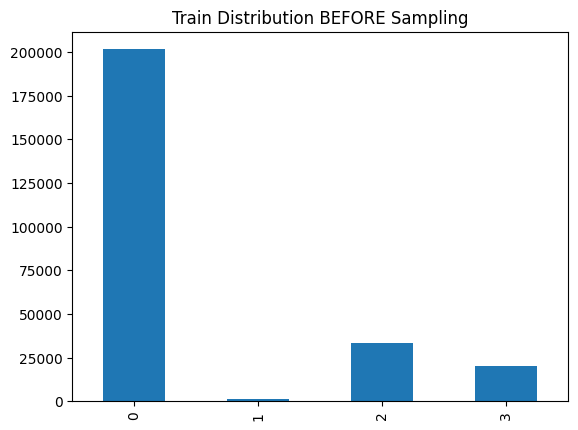

Train distribution AFTER sampling:


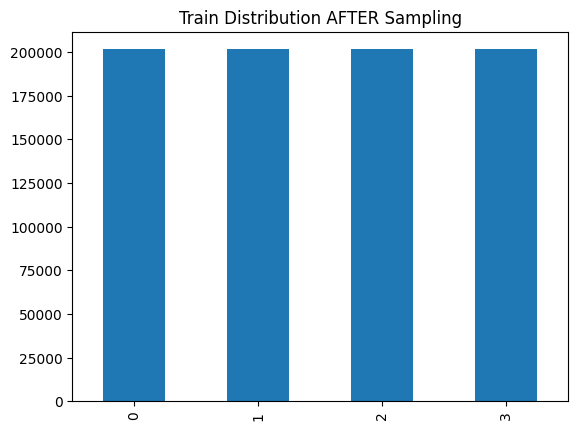

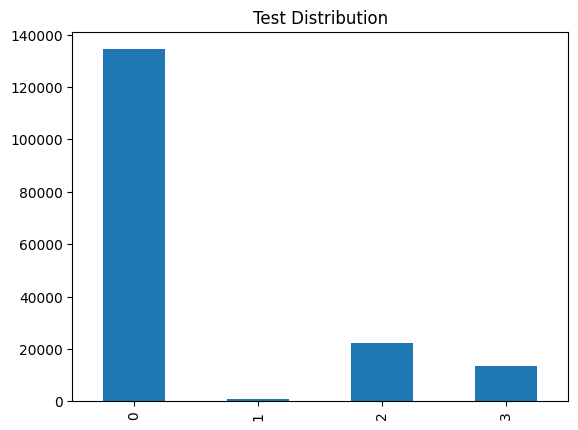

Train size: 806032
Test size : 171050
Epoch 1: Loss=-0.7164, TrainAcc=0.9259, TestAcc=0.9215, ROC-AUC=0.9618
Epoch 2: Loss=-0.7664, TrainAcc=0.9690, TestAcc=0.9230, ROC-AUC=0.9609
Epoch 3: Loss=-0.7701, TrainAcc=0.9710, TestAcc=0.9234, ROC-AUC=0.9611
Epoch 4: Loss=-0.7716, TrainAcc=0.9718, TestAcc=0.9236, ROC-AUC=0.9607
Epoch 5: Loss=-0.7725, TrainAcc=0.9722, TestAcc=0.9244, ROC-AUC=0.9605
Epoch 6: Loss=-0.7732, TrainAcc=0.9725, TestAcc=0.9241, ROC-AUC=0.9607
Epoch 7: Loss=-0.7738, TrainAcc=0.9728, TestAcc=0.9244, ROC-AUC=0.9614
Epoch 8: Loss=-0.7744, TrainAcc=0.9731, TestAcc=0.9252, ROC-AUC=0.9617
Epoch 9: Loss=-0.7749, TrainAcc=0.9734, TestAcc=0.9251, ROC-AUC=0.9619
Epoch 10: Loss=-0.7753, TrainAcc=0.9737, TestAcc=0.9248, ROC-AUC=0.9620
Epoch 11: Loss=-0.7757, TrainAcc=0.9740, TestAcc=0.9257, ROC-AUC=0.9621
Epoch 12: Loss=-0.7760, TrainAcc=0.9740, TestAcc=0.9250, ROC-AUC=0.9623
Epoch 13: Loss=-0.7763, TrainAcc=0.9742, TestAcc=0.9256, ROC-AUC=0.9624
Epoch 14: Loss=-0.7765, TrainAcc=0.

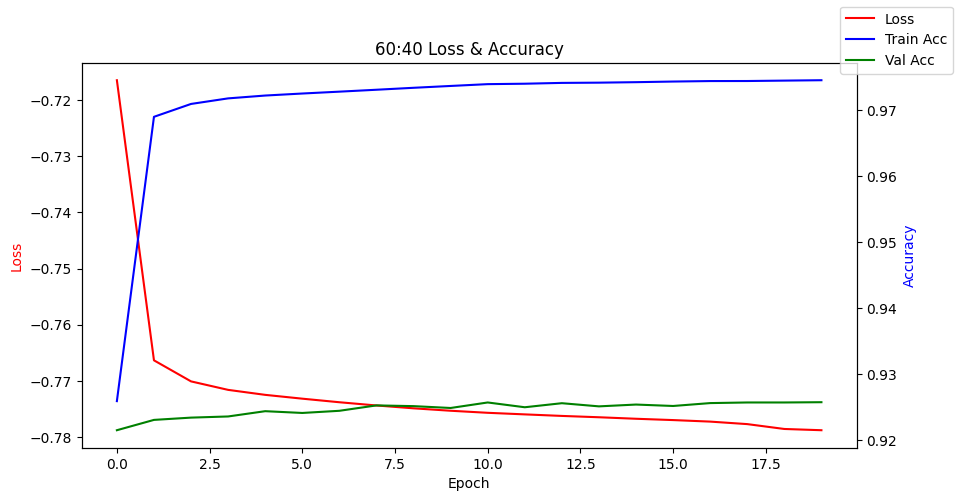

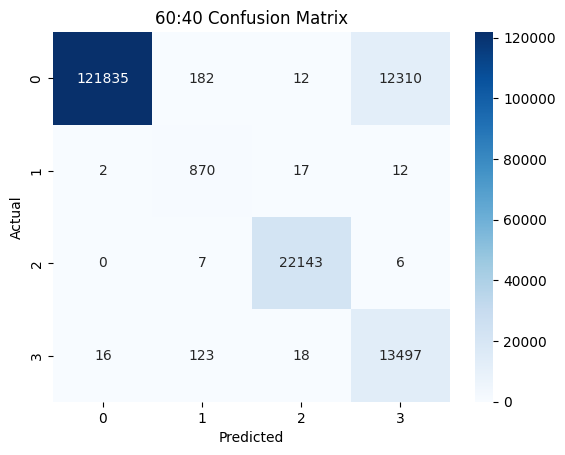

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    134339
           1       0.74      0.97      0.84       901
           2       1.00      1.00      1.00     22156
           3       0.52      0.99      0.68     13654

    accuracy                           0.93    171050
   macro avg       0.81      0.97      0.87    171050
weighted avg       0.96      0.93      0.94    171050



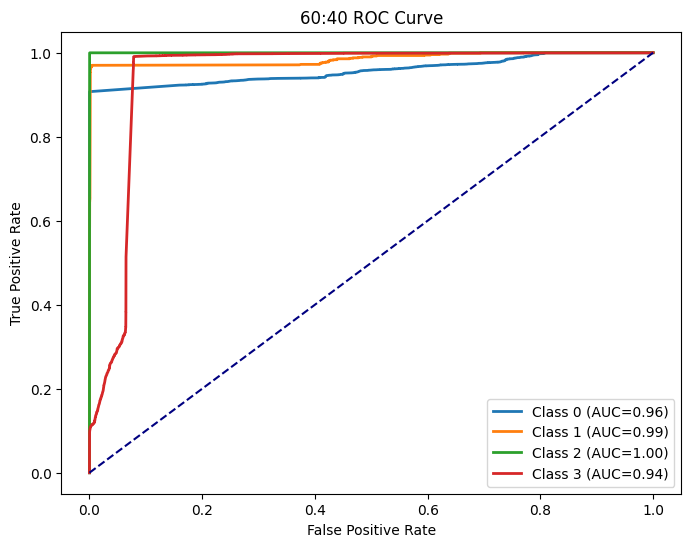

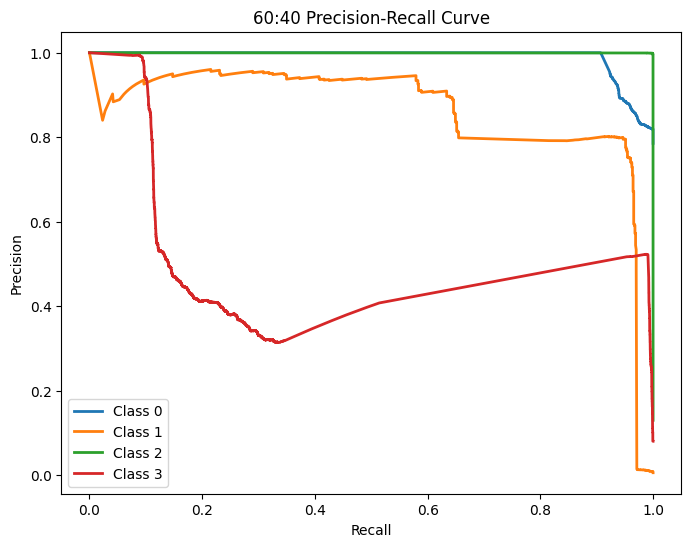


⏱️ Runtime for 60:40: 956.88 sec
💾 RAM used for 60:40: 384.88 MB

========== 70:30 ==========
Train distribution BEFORE sampling:


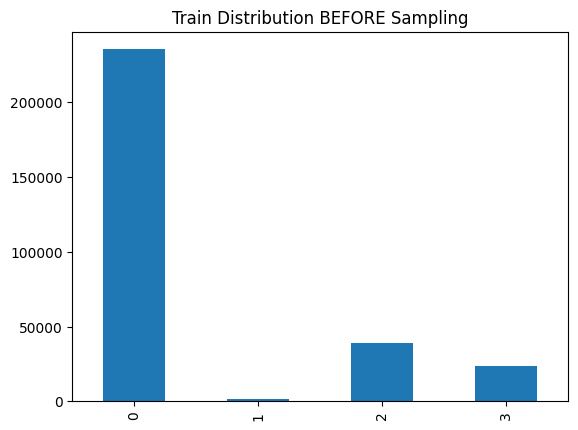

Train distribution AFTER sampling:


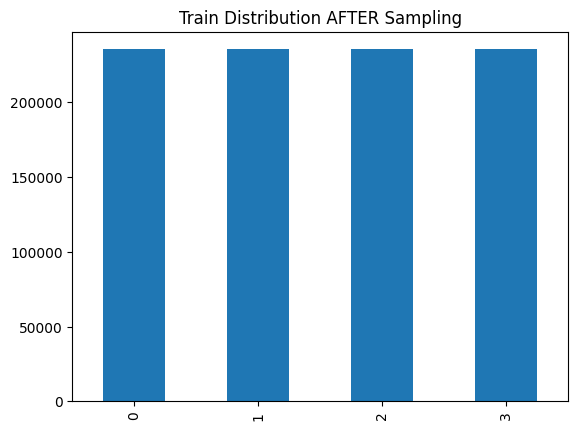

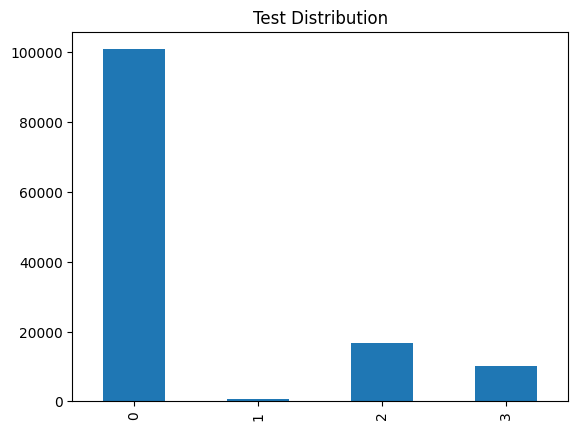

Train size: 940368
Test size : 128288
Epoch 1: Loss=-0.7246, TrainAcc=0.9291, TestAcc=0.9224, ROC-AUC=0.9624
Epoch 2: Loss=-0.7704, TrainAcc=0.9704, TestAcc=0.9238, ROC-AUC=0.9596
Epoch 3: Loss=-0.7731, TrainAcc=0.9720, TestAcc=0.9242, ROC-AUC=0.9583
Epoch 4: Loss=-0.7742, TrainAcc=0.9725, TestAcc=0.9241, ROC-AUC=0.9587
Epoch 5: Loss=-0.7748, TrainAcc=0.9730, TestAcc=0.9242, ROC-AUC=0.9602
Epoch 6: Loss=-0.7754, TrainAcc=0.9734, TestAcc=0.9253, ROC-AUC=0.9596
Epoch 7: Loss=-0.7760, TrainAcc=0.9737, TestAcc=0.9248, ROC-AUC=0.9611
Epoch 8: Loss=-0.7764, TrainAcc=0.9740, TestAcc=0.9245, ROC-AUC=0.9623
Epoch 9: Loss=-0.7768, TrainAcc=0.9742, TestAcc=0.9255, ROC-AUC=0.9622
Epoch 10: Loss=-0.7772, TrainAcc=0.9744, TestAcc=0.9252, ROC-AUC=0.9633
Epoch 11: Loss=-0.7774, TrainAcc=0.9746, TestAcc=0.9250, ROC-AUC=0.9637
Epoch 12: Loss=-0.7778, TrainAcc=0.9748, TestAcc=0.9257, ROC-AUC=0.9638
Epoch 13: Loss=-0.7780, TrainAcc=0.9748, TestAcc=0.9255, ROC-AUC=0.9635
Epoch 14: Loss=-0.7783, TrainAcc=0.

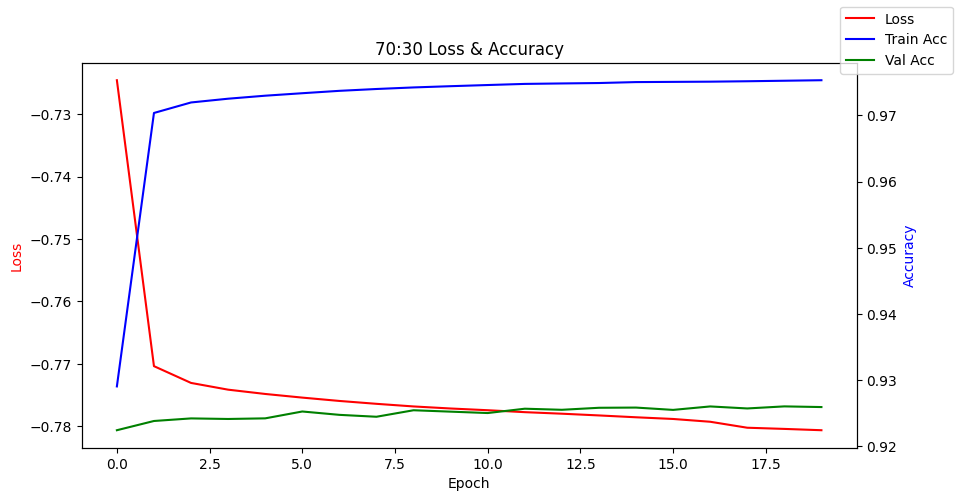

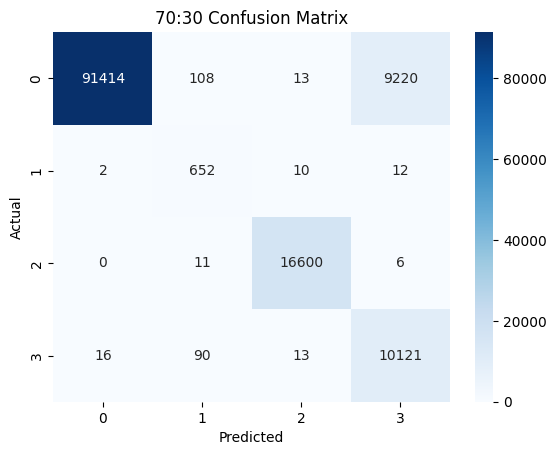

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    100755
           1       0.76      0.96      0.85       676
           2       1.00      1.00      1.00     16617
           3       0.52      0.99      0.68     10240

    accuracy                           0.93    128288
   macro avg       0.82      0.96      0.87    128288
weighted avg       0.96      0.93      0.94    128288



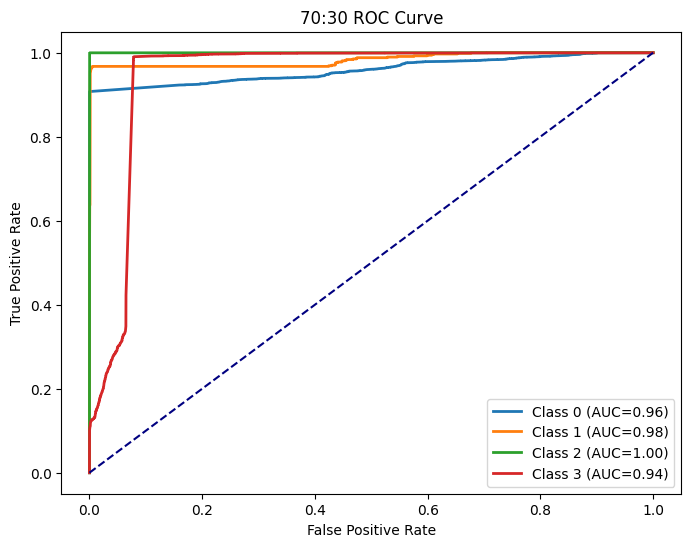

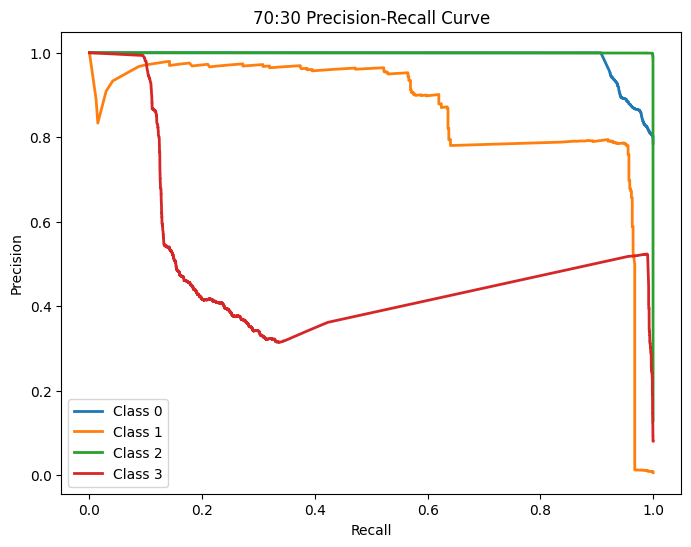


⏱️ Runtime for 70:30: 1092.26 sec
💾 RAM used for 70:30: 410.79 MB

========== 80:20 ==========
Train distribution BEFORE sampling:


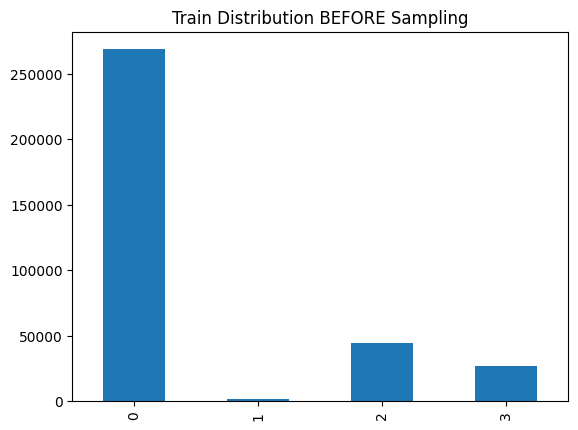

Train distribution AFTER sampling:


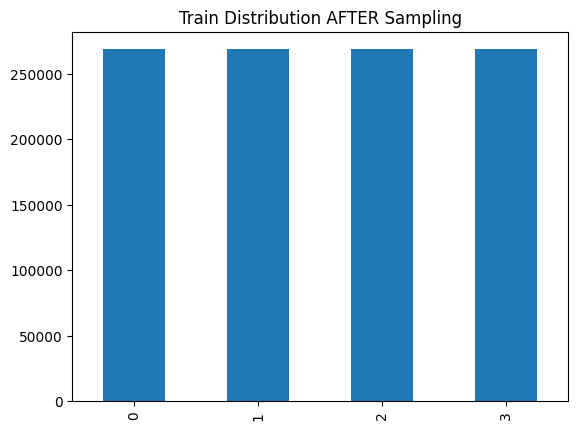

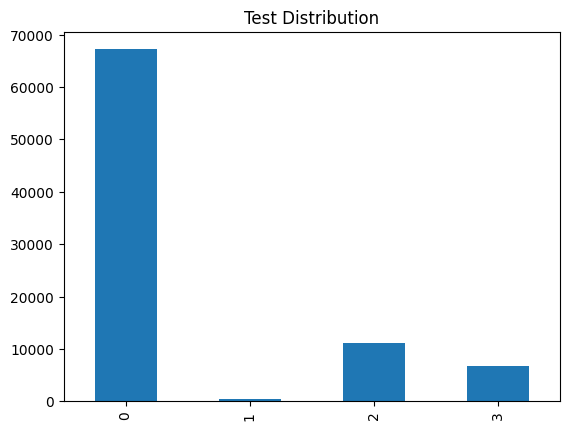

Train size: 1074712
Test size : 85525
Epoch 1: Loss=-0.7313, TrainAcc=0.9349, TestAcc=0.9231, ROC-AUC=0.9617
Epoch 2: Loss=-0.7717, TrainAcc=0.9701, TestAcc=0.9237, ROC-AUC=0.9603
Epoch 3: Loss=-0.7739, TrainAcc=0.9714, TestAcc=0.9245, ROC-AUC=0.9594
Epoch 4: Loss=-0.7750, TrainAcc=0.9721, TestAcc=0.9244, ROC-AUC=0.9601
Epoch 5: Loss=-0.7759, TrainAcc=0.9727, TestAcc=0.9250, ROC-AUC=0.9613
Epoch 6: Loss=-0.7766, TrainAcc=0.9731, TestAcc=0.9250, ROC-AUC=0.9618
Epoch 7: Loss=-0.7771, TrainAcc=0.9733, TestAcc=0.9251, ROC-AUC=0.9631
Epoch 8: Loss=-0.7776, TrainAcc=0.9737, TestAcc=0.9250, ROC-AUC=0.9630
Epoch 9: Loss=-0.7780, TrainAcc=0.9739, TestAcc=0.9256, ROC-AUC=0.9624
Epoch 10: Loss=-0.7783, TrainAcc=0.9742, TestAcc=0.9256, ROC-AUC=0.9602
Epoch 11: Loss=-0.7786, TrainAcc=0.9743, TestAcc=0.9251, ROC-AUC=0.9609
Epoch 12: Loss=-0.7789, TrainAcc=0.9745, TestAcc=0.9260, ROC-AUC=0.9612
Epoch 13: Loss=-0.7795, TrainAcc=0.9746, TestAcc=0.9259, ROC-AUC=0.9603
Epoch 14: Loss=-0.7801, TrainAcc=0.

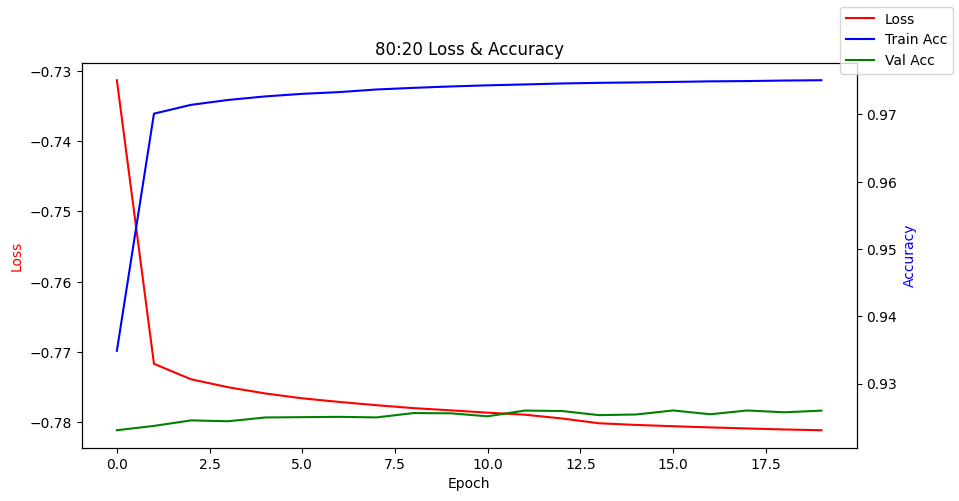

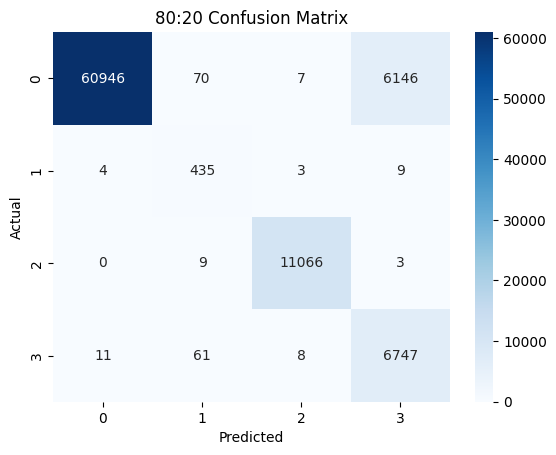

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     67169
           1       0.76      0.96      0.85       451
           2       1.00      1.00      1.00     11078
           3       0.52      0.99      0.68      6827

    accuracy                           0.93     85525
   macro avg       0.82      0.96      0.87     85525
weighted avg       0.96      0.93      0.94     85525



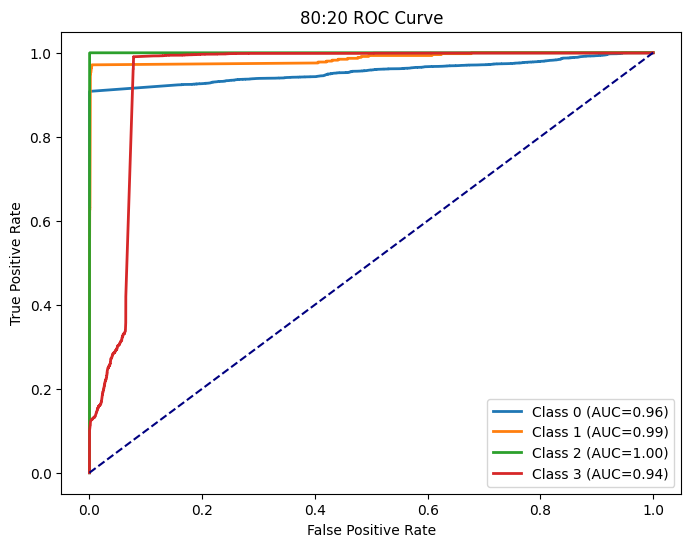

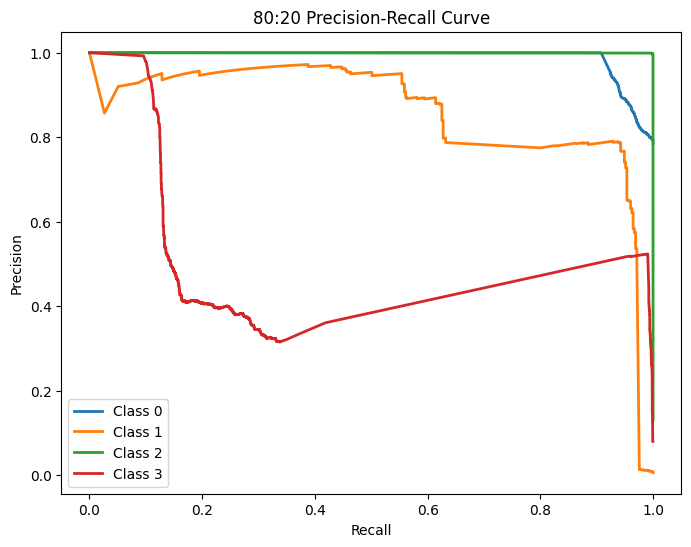


⏱️ Runtime for 80:20: 1230.29 sec
💾 RAM used for 80:20: 452.55 MB


In [36]:
# ---------------- MAIN ---------------- #

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# SMOTE

In [37]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import psutil
import os
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from torch.utils.data import DataLoader
import numpy as np

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    # ⏱️ Start time & RAM
    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # -----------------------------
    # 📊 Train distribution BEFORE SMOTE
    print("Train distribution BEFORE SMOTE:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE SMOTE")
    plt.show()

    # -----------------------------
    # ✅ MinMax Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -----------------------------
    # 🔥 Simple SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # -----------------------------
    # 📊 Train distribution AFTER SMOTE
    print("Train distribution AFTER SMOTE:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER SMOTE")
    plt.show()

    # -----------------------------
    # 📊 Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # -----------------------------
    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # -----------------------------
    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # -----------------------------
    # Training
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # -----------------------------
    # Plot Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # -----------------------------
    # Confusion Matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # -----------------------------
    # ROC Curve (one-vs-rest)
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # ⏱️ End time & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    print(f"\n⏱️ Runtime for {ratio_name}: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used for {ratio_name}: {ram_used:.2f} MB")


========== 60:40 ==========
Train distribution BEFORE SMOTE:


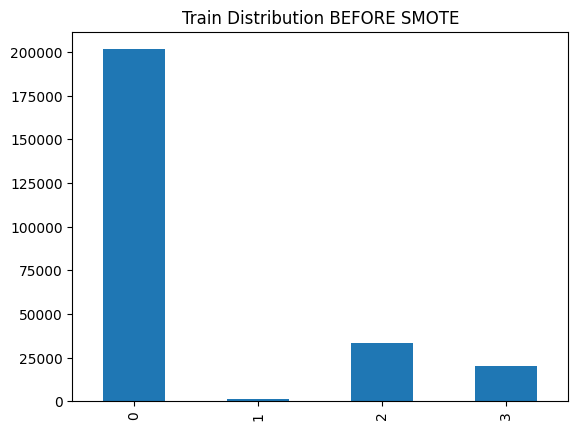

Train distribution AFTER SMOTE:


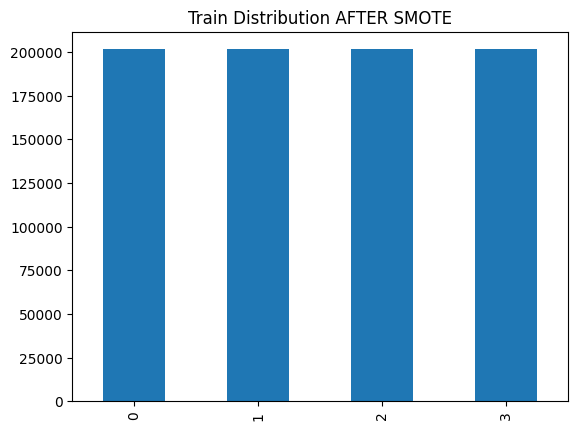

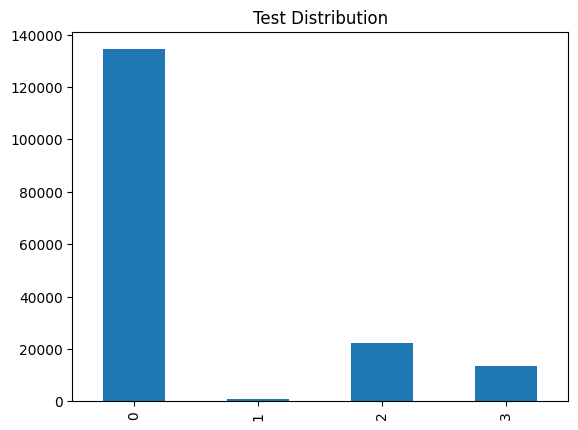

Train size: 806032
Test size : 171050
Epoch 1: Loss=0.1234, TrainAcc=0.9586, TestAcc=0.9727, ROC-AUC=0.9987
Epoch 2: Loss=0.0483, TrainAcc=0.9851, TestAcc=0.9782, ROC-AUC=0.9992
Epoch 3: Loss=0.0390, TrainAcc=0.9880, TestAcc=0.9745, ROC-AUC=0.9992
Epoch 4: Loss=0.0351, TrainAcc=0.9894, TestAcc=0.9776, ROC-AUC=0.9993
Epoch 5: Loss=0.0321, TrainAcc=0.9902, TestAcc=0.9831, ROC-AUC=0.9993
Epoch 6: Loss=0.0301, TrainAcc=0.9908, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 7: Loss=0.0283, TrainAcc=0.9914, TestAcc=0.9737, ROC-AUC=0.9993
Epoch 8: Loss=0.0268, TrainAcc=0.9918, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 9: Loss=0.0256, TrainAcc=0.9921, TestAcc=0.9813, ROC-AUC=0.9994
Epoch 10: Loss=0.0249, TrainAcc=0.9924, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 11: Loss=0.0232, TrainAcc=0.9928, TestAcc=0.9794, ROC-AUC=0.9995
Epoch 12: Loss=0.0225, TrainAcc=0.9929, TestAcc=0.9830, ROC-AUC=0.9995
Epoch 13: Loss=0.0216, TrainAcc=0.9932, TestAcc=0.9808, ROC-AUC=0.9995
Epoch 14: Loss=0.0210, TrainAcc=0.9935, TestAcc=

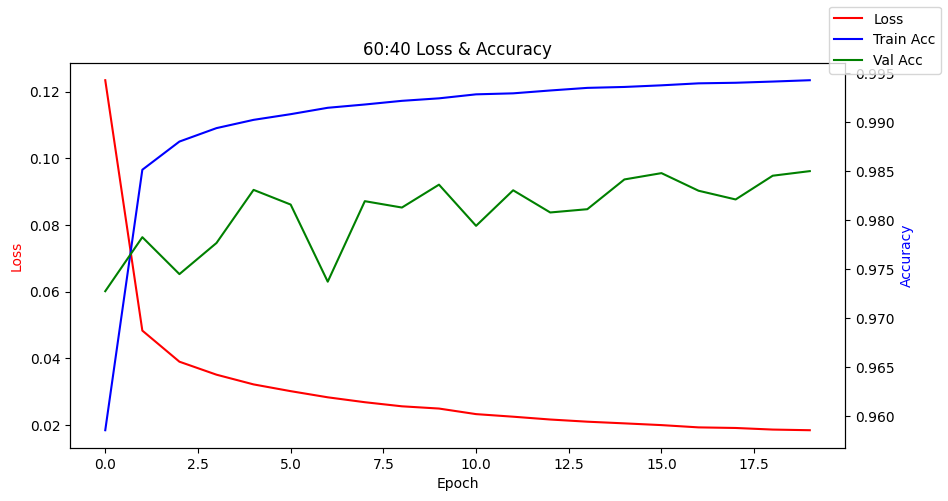

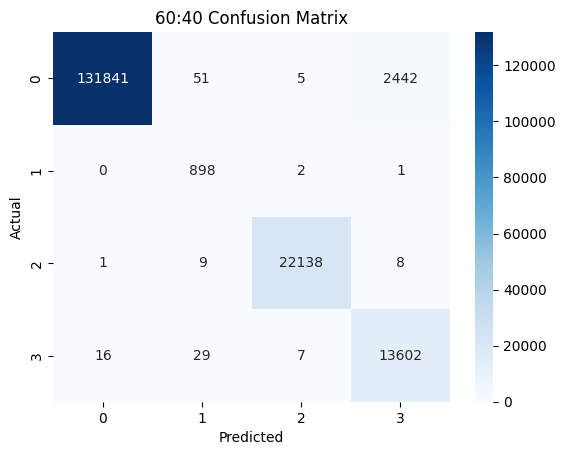

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.91      1.00      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.85      1.00      0.92     13654

    accuracy                           0.98    171050
   macro avg       0.94      0.99      0.96    171050
weighted avg       0.99      0.98      0.99    171050



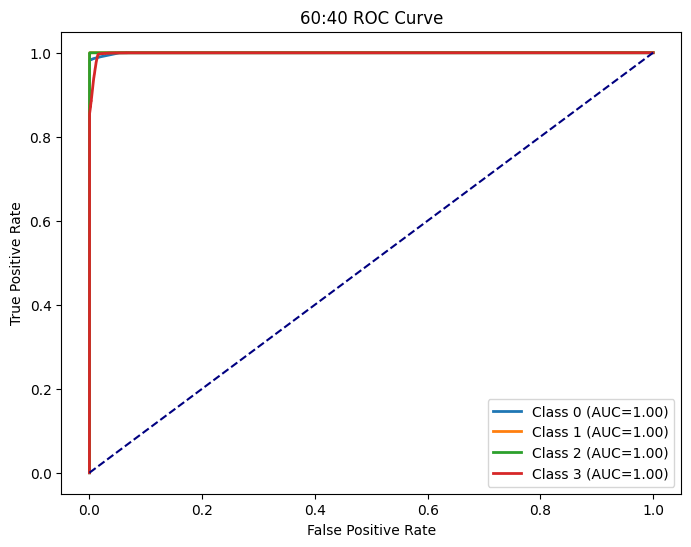

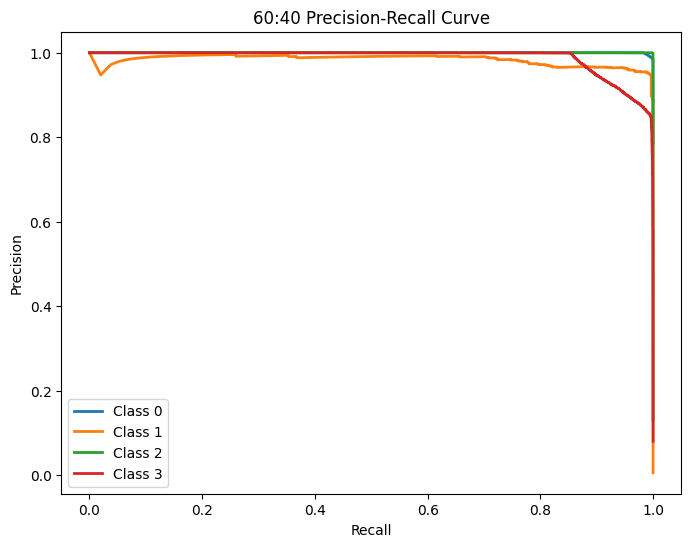


⏱️ Runtime for 60:40: 1094.45 sec
💾 RAM used for 60:40: -1020.37 MB

========== 70:30 ==========
Train distribution BEFORE SMOTE:


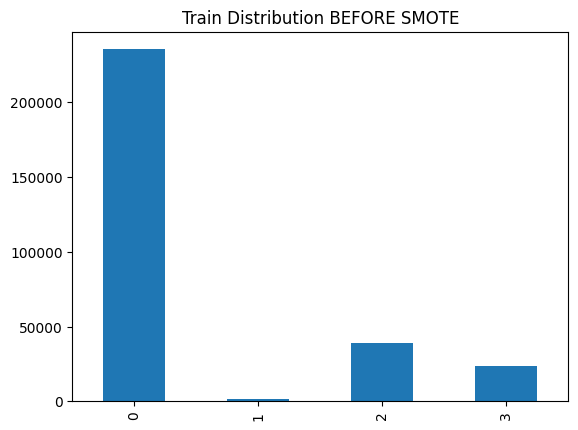

Train distribution AFTER SMOTE:


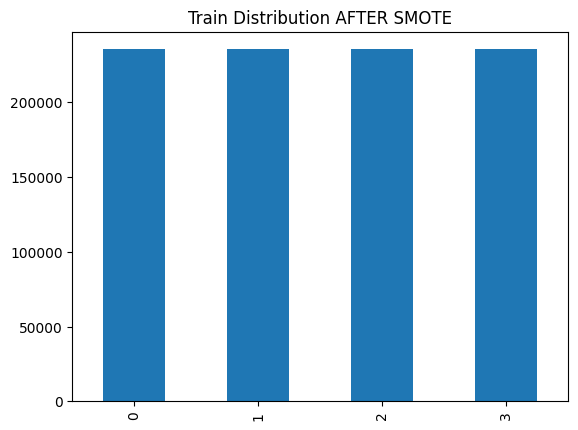

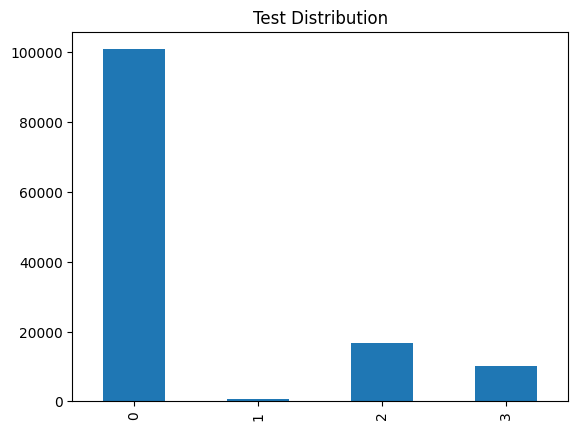

Train size: 940368
Test size : 128288
Epoch 1: Loss=0.1579, TrainAcc=0.9457, TestAcc=0.9454, ROC-AUC=0.9983
Epoch 2: Loss=0.0621, TrainAcc=0.9774, TestAcc=0.9550, ROC-AUC=0.9989
Epoch 3: Loss=0.0471, TrainAcc=0.9845, TestAcc=0.9694, ROC-AUC=0.9992
Epoch 4: Loss=0.0395, TrainAcc=0.9875, TestAcc=0.9761, ROC-AUC=0.9992
Epoch 5: Loss=0.0350, TrainAcc=0.9895, TestAcc=0.9778, ROC-AUC=0.9993
Epoch 6: Loss=0.0322, TrainAcc=0.9907, TestAcc=0.9800, ROC-AUC=0.9994
Epoch 7: Loss=0.0301, TrainAcc=0.9914, TestAcc=0.9790, ROC-AUC=0.9994
Epoch 8: Loss=0.0288, TrainAcc=0.9918, TestAcc=0.9806, ROC-AUC=0.9994
Epoch 9: Loss=0.0276, TrainAcc=0.9921, TestAcc=0.9805, ROC-AUC=0.9994
Epoch 10: Loss=0.0267, TrainAcc=0.9923, TestAcc=0.9822, ROC-AUC=0.9994
Epoch 11: Loss=0.0261, TrainAcc=0.9925, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 12: Loss=0.0257, TrainAcc=0.9926, TestAcc=0.9784, ROC-AUC=0.9994
Epoch 13: Loss=0.0249, TrainAcc=0.9928, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 14: Loss=0.0244, TrainAcc=0.9928, TestAcc=

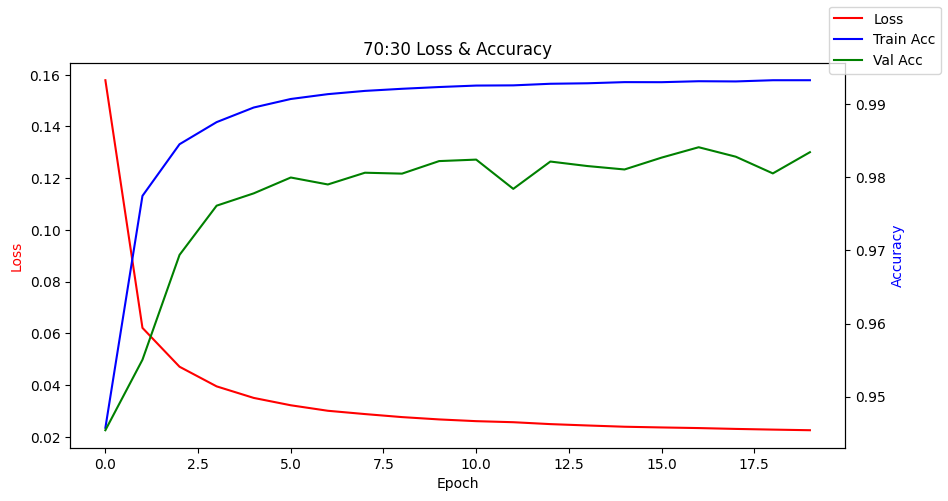

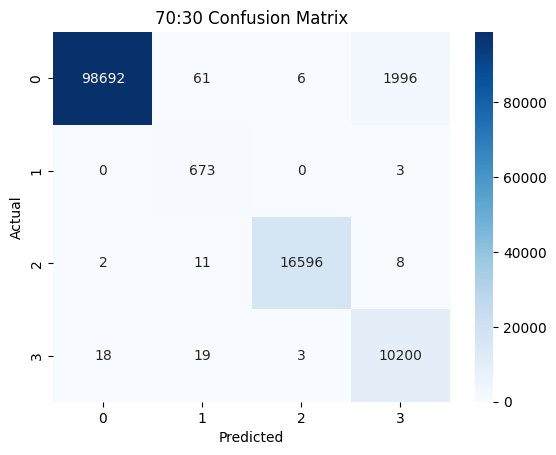

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.88      1.00      0.93       676
           2       1.00      1.00      1.00     16617
           3       0.84      1.00      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.93      0.99      0.96    128288
weighted avg       0.99      0.98      0.98    128288



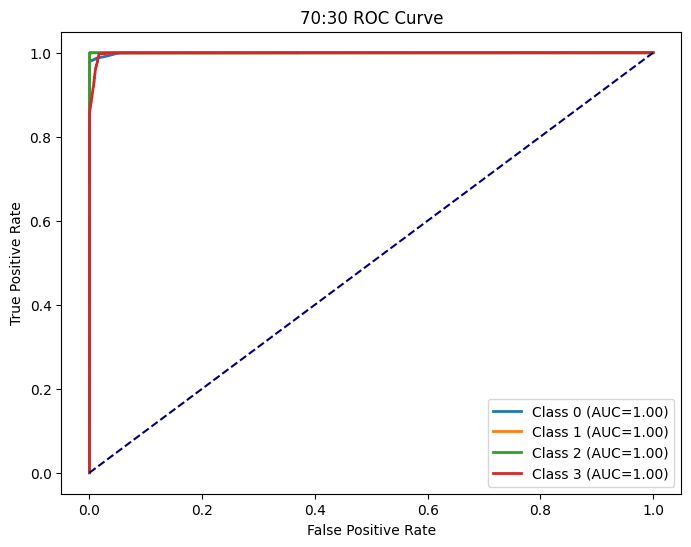

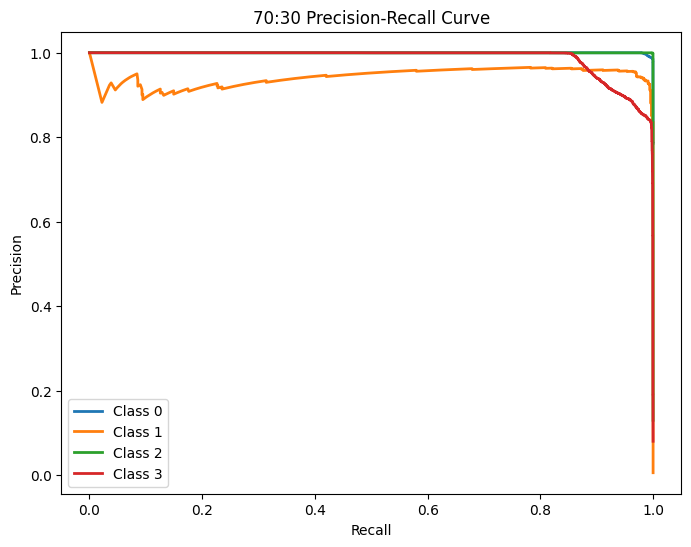


⏱️ Runtime for 70:30: 1244.31 sec
💾 RAM used for 70:30: 339.59 MB

========== 80:20 ==========
Train distribution BEFORE SMOTE:


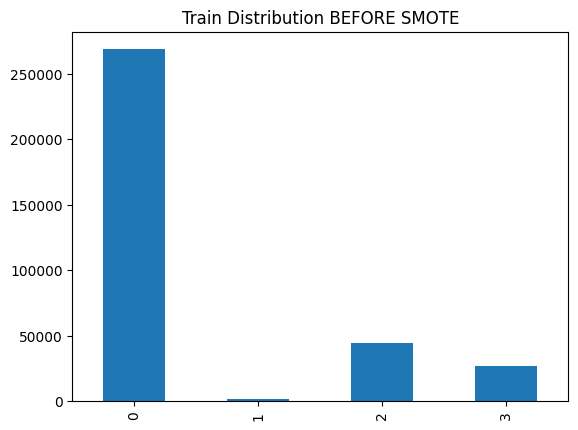

Train distribution AFTER SMOTE:


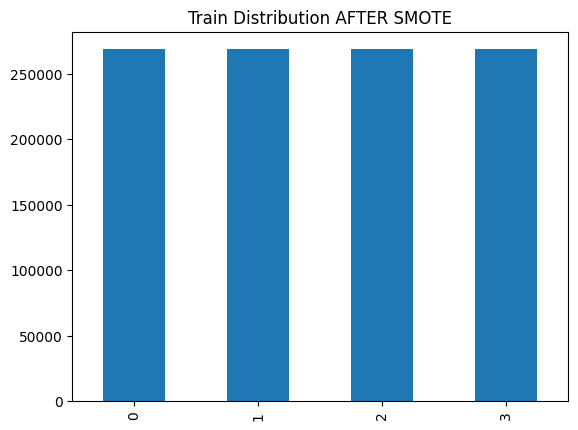

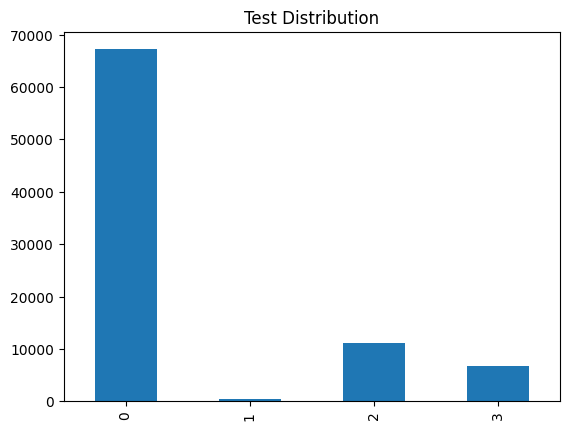

Train size: 1074712
Test size : 85525
Epoch 1: Loss=0.1120, TrainAcc=0.9610, TestAcc=0.9523, ROC-AUC=0.9973
Epoch 2: Loss=0.0522, TrainAcc=0.9822, TestAcc=0.9678, ROC-AUC=0.9988
Epoch 3: Loss=0.0390, TrainAcc=0.9873, TestAcc=0.9776, ROC-AUC=0.9992
Epoch 4: Loss=0.0332, TrainAcc=0.9893, TestAcc=0.9795, ROC-AUC=0.9993
Epoch 5: Loss=0.0300, TrainAcc=0.9907, TestAcc=0.9790, ROC-AUC=0.9993
Epoch 6: Loss=0.0275, TrainAcc=0.9915, TestAcc=0.9805, ROC-AUC=0.9993
Epoch 7: Loss=0.0262, TrainAcc=0.9919, TestAcc=0.9834, ROC-AUC=0.9994
Epoch 8: Loss=0.0253, TrainAcc=0.9922, TestAcc=0.9791, ROC-AUC=0.9994
Epoch 9: Loss=0.0244, TrainAcc=0.9925, TestAcc=0.9781, ROC-AUC=0.9994
Epoch 10: Loss=0.0236, TrainAcc=0.9926, TestAcc=0.9793, ROC-AUC=0.9995
Epoch 11: Loss=0.0229, TrainAcc=0.9928, TestAcc=0.9806, ROC-AUC=0.9994
Epoch 12: Loss=0.0225, TrainAcc=0.9930, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 13: Loss=0.0220, TrainAcc=0.9931, TestAcc=0.9832, ROC-AUC=0.9995
Epoch 14: Loss=0.0215, TrainAcc=0.9933, TestAcc=

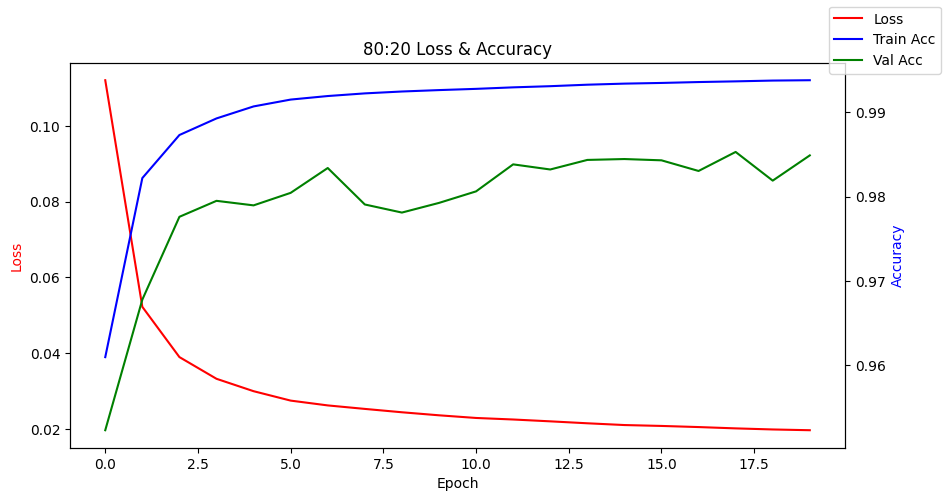

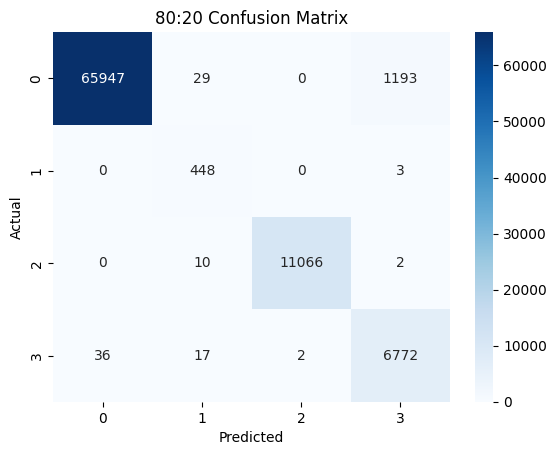

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.89      0.99      0.94       451
           2       1.00      1.00      1.00     11078
           3       0.85      0.99      0.92      6827

    accuracy                           0.98     85525
   macro avg       0.93      0.99      0.96     85525
weighted avg       0.99      0.98      0.99     85525



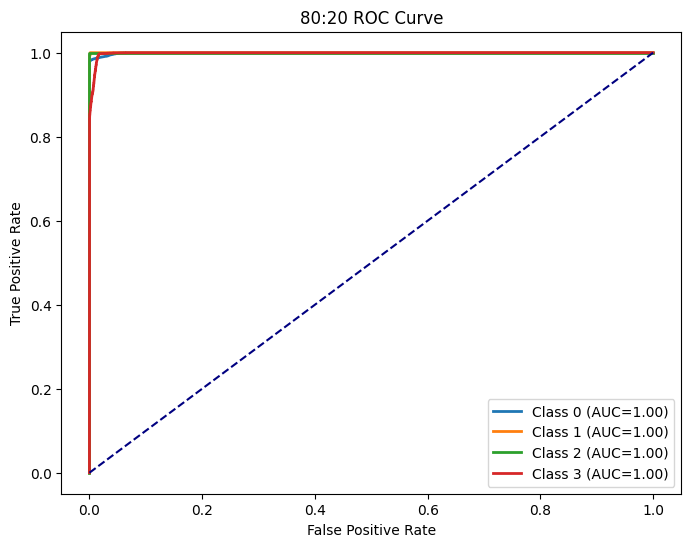

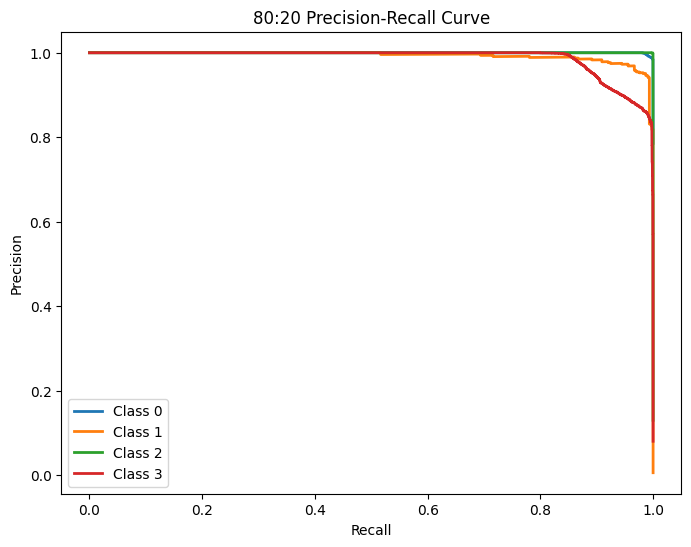


⏱️ Runtime for 80:20: 1386.48 sec
💾 RAM used for 80:20: 378.47 MB


In [38]:
# ---------------- MAIN ---------------- #

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# ADASYN

In [39]:
from imblearn.over_sampling import ADASYN
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import psutil
import os
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from torch.utils.data import DataLoader
import numpy as np

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    # ⏱️ Start time & RAM
    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # -----------------------------
    # 📊 Train distribution BEFORE ADASYN
    print("Train distribution BEFORE ADASYN:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE ADASYN")
    plt.show()

    # -----------------------------
    # ✅ MinMax Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -----------------------------
    # 🔥 ADASYN oversampling
    adasyn = ADASYN(random_state=42)
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # -----------------------------
    # 📊 Train distribution AFTER ADASYN
    print("Train distribution AFTER ADASYN:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER ADASYN")
    plt.show()

    # -----------------------------
    # 📊 Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # -----------------------------
    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # -----------------------------
    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # -----------------------------
    # Training
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # -----------------------------
    # Plot Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # -----------------------------
    # Confusion Matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # -----------------------------
    # ROC Curve (one-vs-rest)
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # ⏱️ End time & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    print(f"\n⏱️ Runtime for {ratio_name}: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used for {ratio_name}: {ram_used:.2f} MB")


========== 60:40 ==========
Train distribution BEFORE ADASYN:


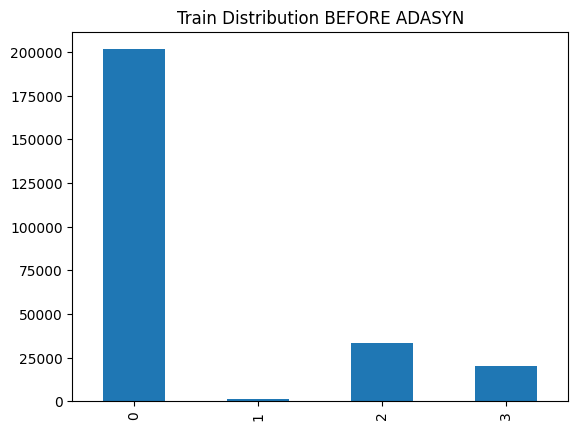

Train distribution AFTER ADASYN:


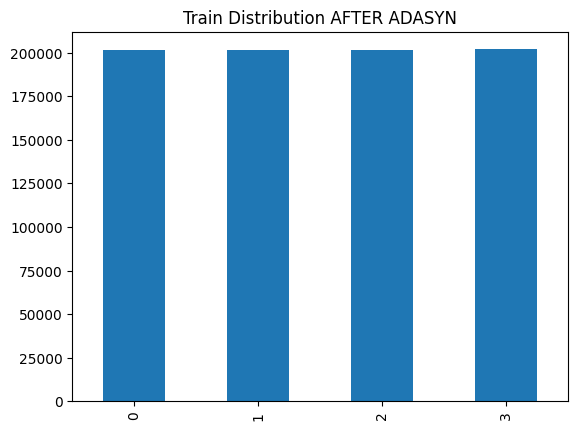

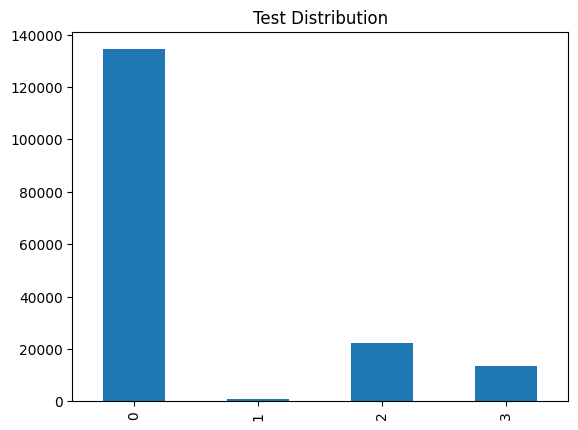

Train size: 806280
Test size : 171050
Epoch 1: Loss=0.2646, TrainAcc=0.9121, TestAcc=0.9395, ROC-AUC=0.9924
Epoch 2: Loss=0.1000, TrainAcc=0.9714, TestAcc=0.9664, ROC-AUC=0.9958
Epoch 3: Loss=0.0733, TrainAcc=0.9811, TestAcc=0.9687, ROC-AUC=0.9967
Epoch 4: Loss=0.0629, TrainAcc=0.9845, TestAcc=0.9684, ROC-AUC=0.9971
Epoch 5: Loss=0.0570, TrainAcc=0.9861, TestAcc=0.9716, ROC-AUC=0.9975
Epoch 6: Loss=0.0528, TrainAcc=0.9872, TestAcc=0.9722, ROC-AUC=0.9977
Epoch 7: Loss=0.0496, TrainAcc=0.9881, TestAcc=0.9748, ROC-AUC=0.9980
Epoch 8: Loss=0.0475, TrainAcc=0.9888, TestAcc=0.9751, ROC-AUC=0.9982
Epoch 9: Loss=0.0457, TrainAcc=0.9893, TestAcc=0.9748, ROC-AUC=0.9984
Epoch 10: Loss=0.0443, TrainAcc=0.9897, TestAcc=0.9755, ROC-AUC=0.9983
Epoch 11: Loss=0.0432, TrainAcc=0.9900, TestAcc=0.9755, ROC-AUC=0.9984
Epoch 12: Loss=0.0423, TrainAcc=0.9904, TestAcc=0.9757, ROC-AUC=0.9983
Epoch 13: Loss=0.0414, TrainAcc=0.9906, TestAcc=0.9774, ROC-AUC=0.9985
Epoch 14: Loss=0.0408, TrainAcc=0.9908, TestAcc=

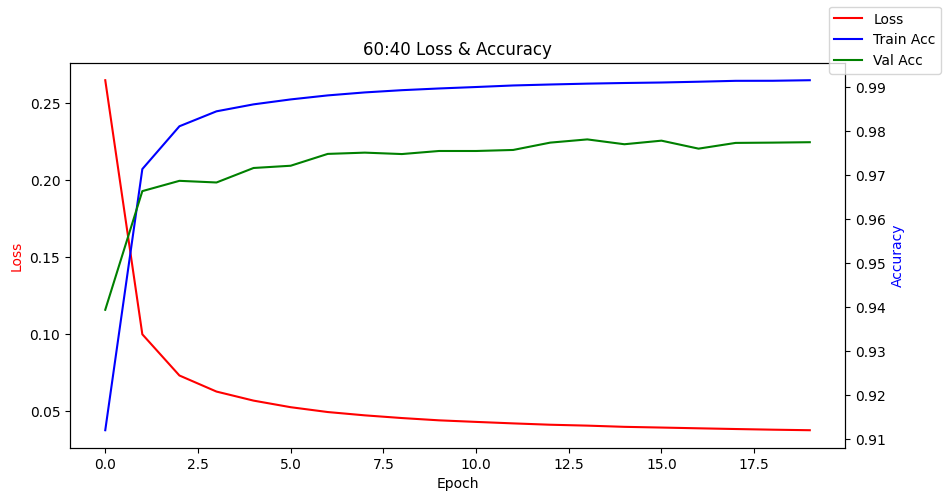

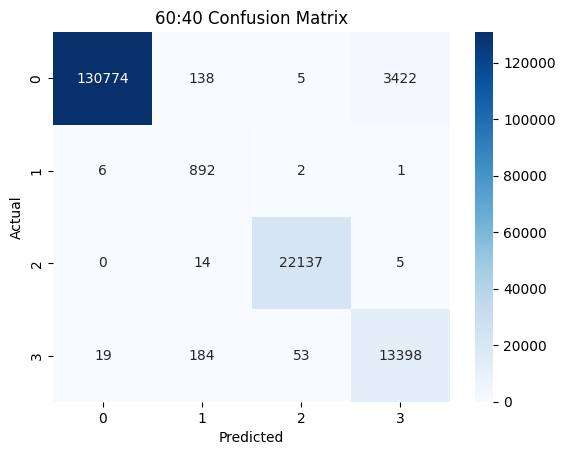

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    134339
           1       0.73      0.99      0.84       901
           2       1.00      1.00      1.00     22156
           3       0.80      0.98      0.88     13654

    accuracy                           0.98    171050
   macro avg       0.88      0.99      0.93    171050
weighted avg       0.98      0.98      0.98    171050



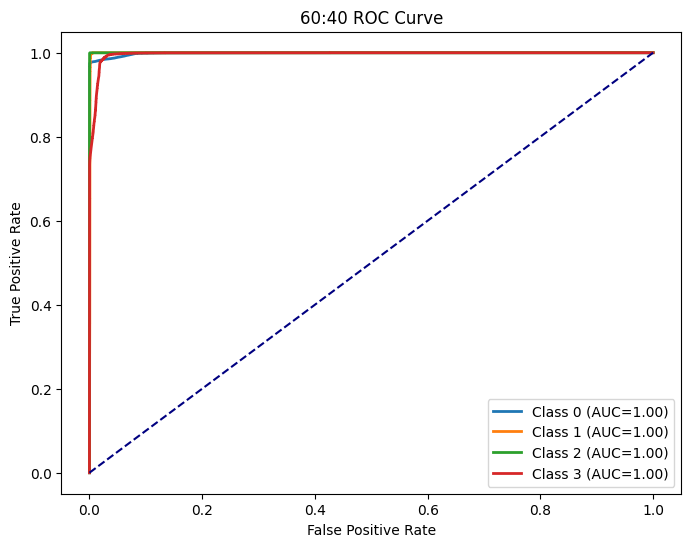

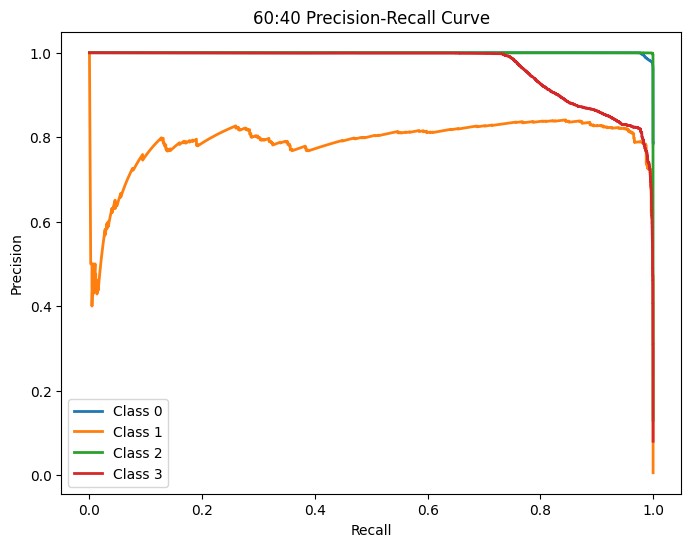


⏱️ Runtime for 60:40: 1116.55 sec
💾 RAM used for 60:40: 280.36 MB

========== 70:30 ==========
Train distribution BEFORE ADASYN:


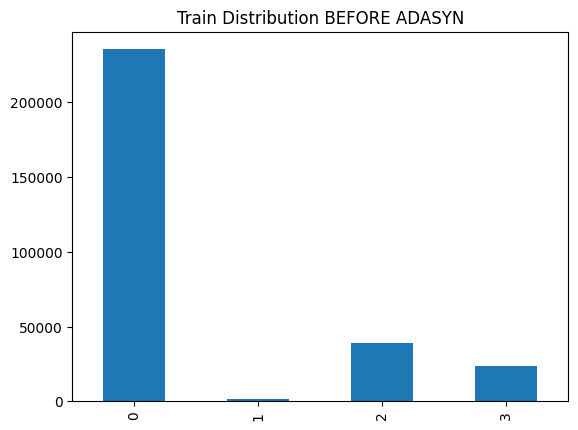

Train distribution AFTER ADASYN:


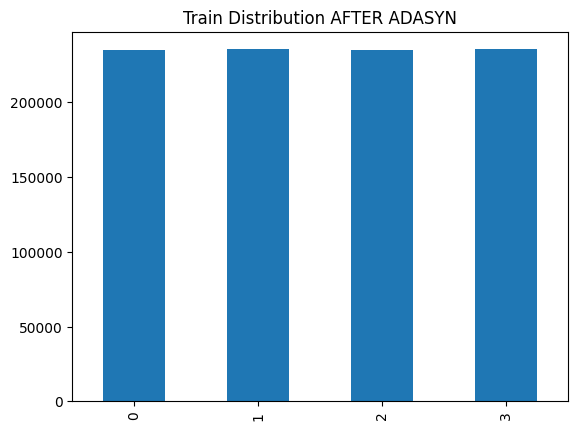

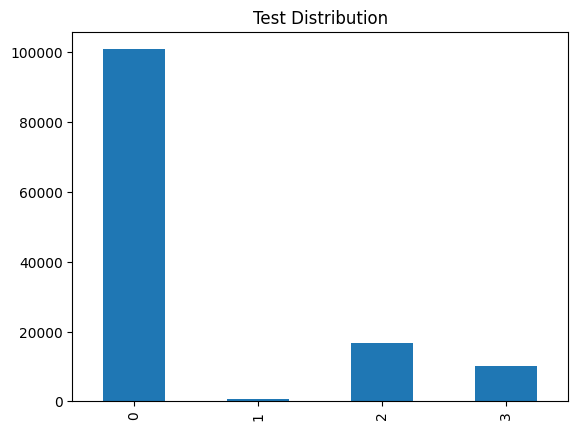

Train size: 940512
Test size : 128288
Epoch 1: Loss=0.2533, TrainAcc=0.9152, TestAcc=0.9417, ROC-AUC=0.9923
Epoch 2: Loss=0.1061, TrainAcc=0.9680, TestAcc=0.9626, ROC-AUC=0.9951
Epoch 3: Loss=0.0761, TrainAcc=0.9812, TestAcc=0.9698, ROC-AUC=0.9963
Epoch 4: Loss=0.0632, TrainAcc=0.9852, TestAcc=0.9718, ROC-AUC=0.9970
Epoch 5: Loss=0.0561, TrainAcc=0.9868, TestAcc=0.9708, ROC-AUC=0.9972
Epoch 6: Loss=0.0516, TrainAcc=0.9879, TestAcc=0.9765, ROC-AUC=0.9978
Epoch 7: Loss=0.0483, TrainAcc=0.9887, TestAcc=0.9739, ROC-AUC=0.9980
Epoch 8: Loss=0.0460, TrainAcc=0.9894, TestAcc=0.9753, ROC-AUC=0.9979
Epoch 9: Loss=0.0442, TrainAcc=0.9899, TestAcc=0.9759, ROC-AUC=0.9981
Epoch 10: Loss=0.0427, TrainAcc=0.9904, TestAcc=0.9761, ROC-AUC=0.9982
Epoch 11: Loss=0.0417, TrainAcc=0.9907, TestAcc=0.9772, ROC-AUC=0.9981
Epoch 12: Loss=0.0407, TrainAcc=0.9909, TestAcc=0.9777, ROC-AUC=0.9984
Epoch 13: Loss=0.0399, TrainAcc=0.9911, TestAcc=0.9765, ROC-AUC=0.9984
Epoch 14: Loss=0.0393, TrainAcc=0.9913, TestAcc=

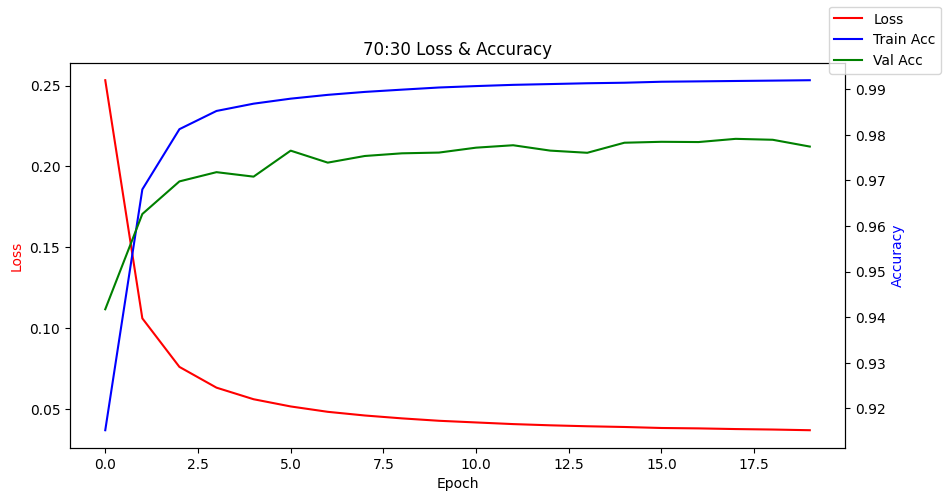

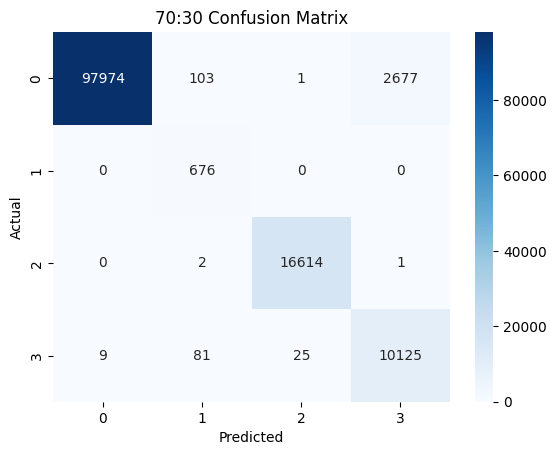

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    100755
           1       0.78      1.00      0.88       676
           2       1.00      1.00      1.00     16617
           3       0.79      0.99      0.88     10240

    accuracy                           0.98    128288
   macro avg       0.89      0.99      0.94    128288
weighted avg       0.98      0.98      0.98    128288



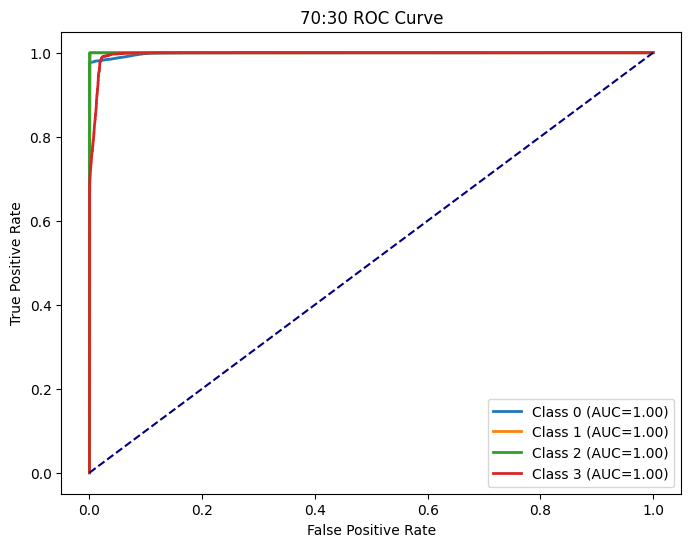

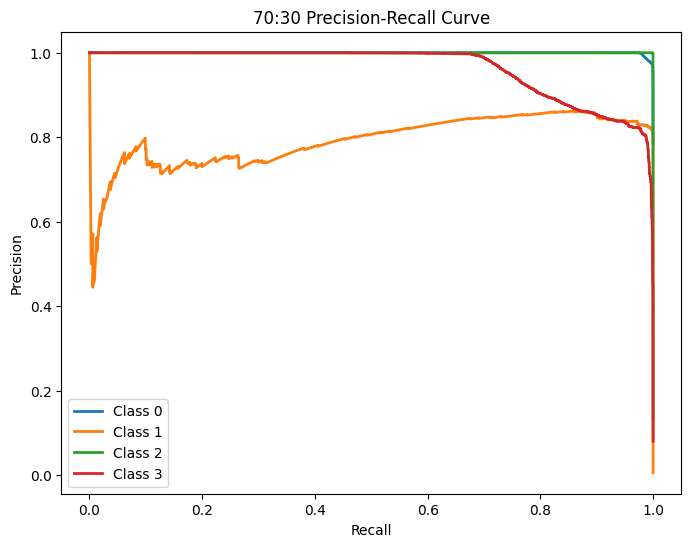


⏱️ Runtime for 70:30: 1286.50 sec
💾 RAM used for 70:30: 334.62 MB

========== 80:20 ==========
Train distribution BEFORE ADASYN:


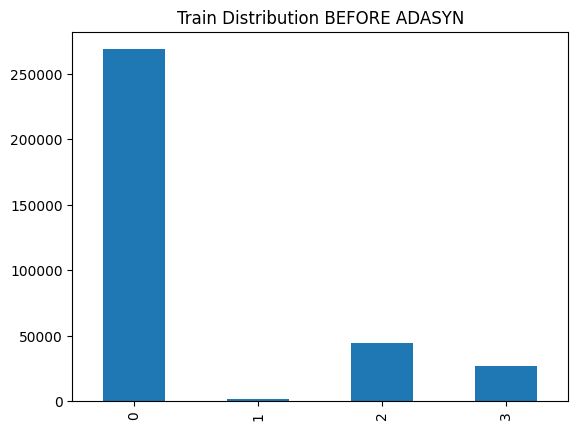

Train distribution AFTER ADASYN:


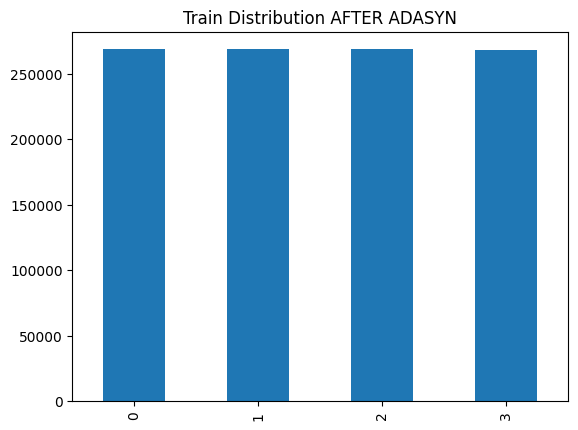

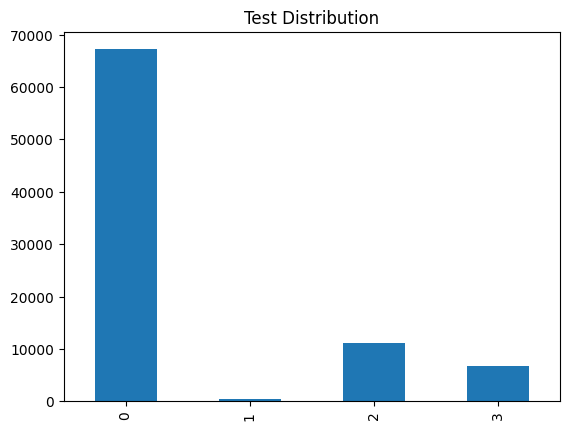

Train size: 1074568
Test size : 85525
Epoch 1: Loss=0.2360, TrainAcc=0.9193, TestAcc=0.9556, ROC-AUC=0.9944
Epoch 2: Loss=0.0826, TrainAcc=0.9790, TestAcc=0.9702, ROC-AUC=0.9968
Epoch 3: Loss=0.0600, TrainAcc=0.9863, TestAcc=0.9742, ROC-AUC=0.9975
Epoch 4: Loss=0.0519, TrainAcc=0.9882, TestAcc=0.9748, ROC-AUC=0.9979
Epoch 5: Loss=0.0475, TrainAcc=0.9891, TestAcc=0.9747, ROC-AUC=0.9982
Epoch 6: Loss=0.0449, TrainAcc=0.9897, TestAcc=0.9774, ROC-AUC=0.9986
Epoch 7: Loss=0.0429, TrainAcc=0.9903, TestAcc=0.9777, ROC-AUC=0.9985
Epoch 8: Loss=0.0414, TrainAcc=0.9906, TestAcc=0.9770, ROC-AUC=0.9984
Epoch 9: Loss=0.0403, TrainAcc=0.9909, TestAcc=0.9774, ROC-AUC=0.9986
Epoch 10: Loss=0.0396, TrainAcc=0.9911, TestAcc=0.9775, ROC-AUC=0.9986
Epoch 11: Loss=0.0388, TrainAcc=0.9913, TestAcc=0.9778, ROC-AUC=0.9988
Epoch 12: Loss=0.0381, TrainAcc=0.9915, TestAcc=0.9780, ROC-AUC=0.9986
Epoch 13: Loss=0.0374, TrainAcc=0.9916, TestAcc=0.9789, ROC-AUC=0.9989
Epoch 14: Loss=0.0369, TrainAcc=0.9918, TestAcc=

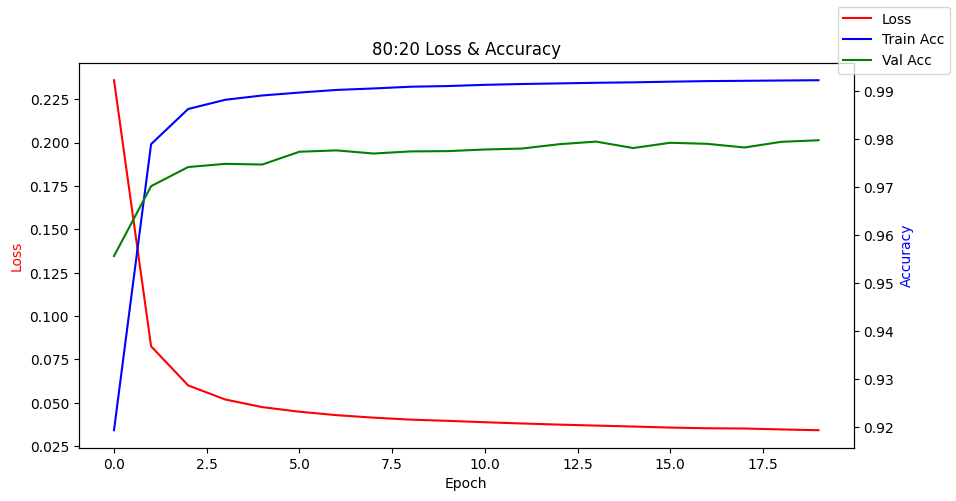

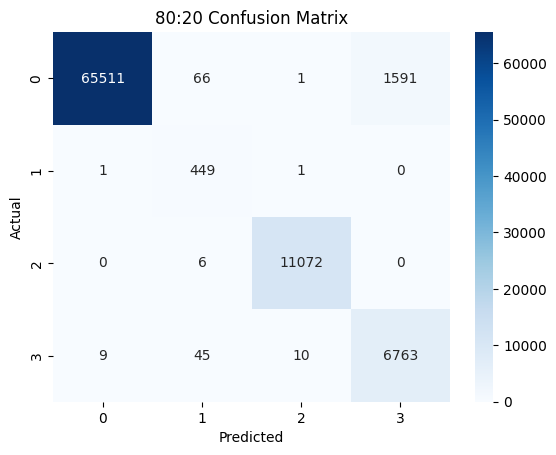

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.79      1.00      0.88       451
           2       1.00      1.00      1.00     11078
           3       0.81      0.99      0.89      6827

    accuracy                           0.98     85525
   macro avg       0.90      0.99      0.94     85525
weighted avg       0.98      0.98      0.98     85525



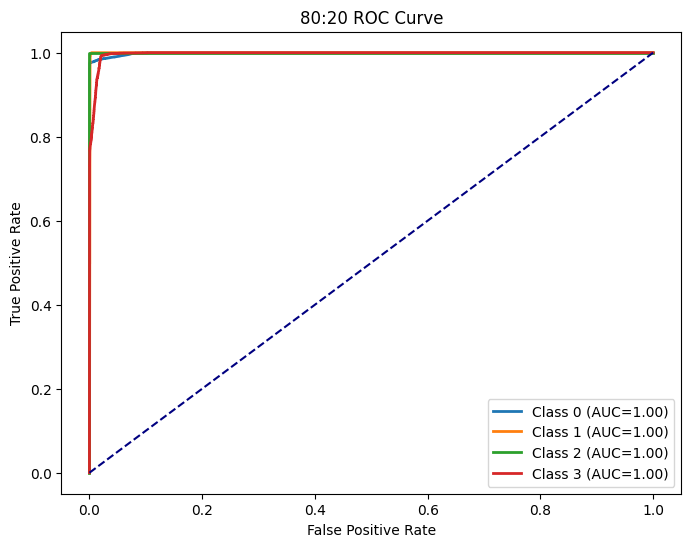

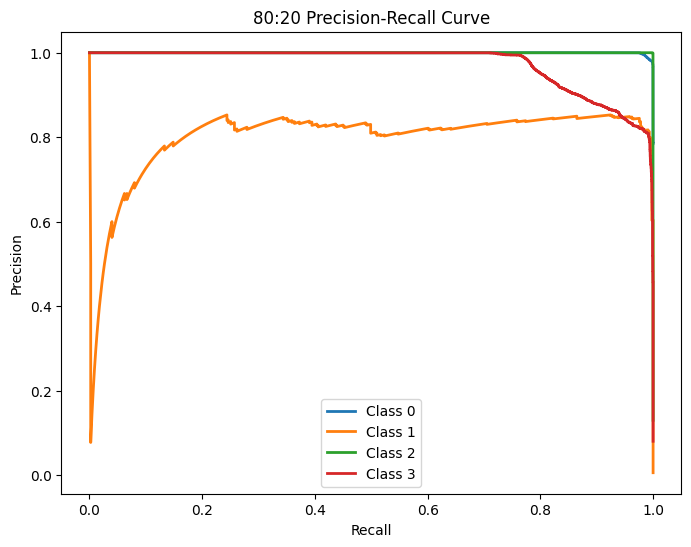


⏱️ Runtime for 80:20: 1446.79 sec
💾 RAM used for 80:20: 375.45 MB


In [40]:
# ---------------- MAIN ---------------- #

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# ADASYN + Tomek_Links

In [41]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import psutil
import os
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from torch.utils.data import DataLoader
import numpy as np

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    # ⏱️ Start time & RAM
    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # -----------------------------
    # 📊 Train distribution BEFORE ADASYN+Tomek
    print("Train distribution BEFORE ADASYN+Tomek:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution BEFORE ADASYN+Tomek")
    plt.show()

    # -----------------------------
    # ✅ MinMax Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -----------------------------
    # 🔥 ADASYN oversampling
    adasyn = ADASYN(random_state=42)
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # -----------------------------
    # 🔥 Tomek Links undersampling
    tomek = TomekLinks()
    X_train, y_train = tomek.fit_resample(X_train, y_train)

    # -----------------------------
    # 📊 Train distribution AFTER ADASYN+Tomek
    print("Train distribution AFTER ADASYN+Tomek:")
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution AFTER ADASYN+Tomek")
    plt.show()

    # -----------------------------
    # 📊 Test distribution
    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    # -----------------------------
    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # -----------------------------
    # Model
    model = GatedFusionModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # -----------------------------
    # Training
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # -----------------------------
    # Plot Loss & Accuracy
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc", color="blue")
    ax2.plot(history["val_acc"], label="Val Acc", color="green")
    ax2.set_ylabel("Accuracy", color="blue")
    fig.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # -----------------------------
    # Confusion Matrix
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # -----------------------------
    # ROC Curve (one-vs-rest)
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1], color="navy", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{ratio_name} ROC Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # Precision-Recall Curve
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:,i], probs[:,i])
        plt.plot(recall, precision, lw=2, label=f"Class {i}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ratio_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -----------------------------
    # ⏱️ End time & RAM
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    print(f"\n⏱️ Runtime for {ratio_name}: {end_time - start_time:.2f} sec")
    print(f"💾 RAM used for {ratio_name}: {ram_used:.2f} MB")


========== 60:40 ==========
Train distribution BEFORE ADASYN+Tomek:


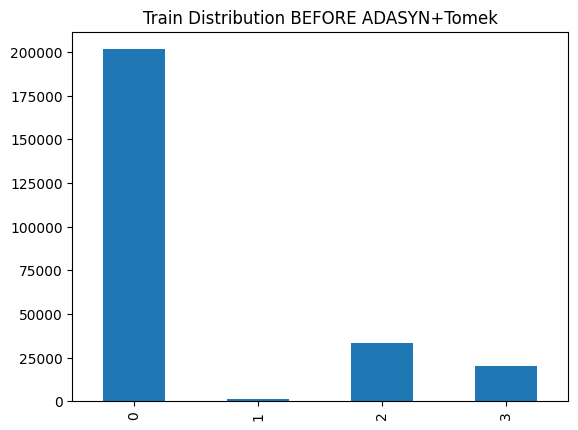

Train distribution AFTER ADASYN+Tomek:


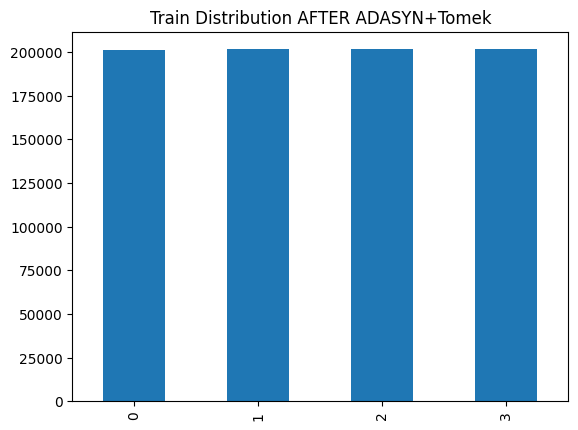

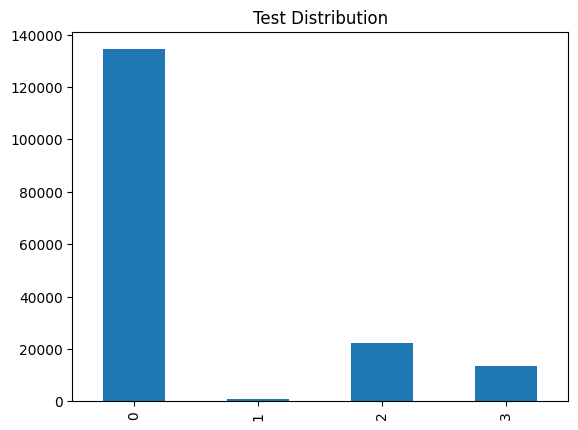

Train size: 805670
Test size : 171050
Epoch 1: Loss=0.2636, TrainAcc=0.9122, TestAcc=0.9531, ROC-AUC=0.9941
Epoch 2: Loss=0.0982, TrainAcc=0.9722, TestAcc=0.9682, ROC-AUC=0.9967
Epoch 3: Loss=0.0679, TrainAcc=0.9832, TestAcc=0.9729, ROC-AUC=0.9981
Epoch 4: Loss=0.0565, TrainAcc=0.9864, TestAcc=0.9740, ROC-AUC=0.9985
Epoch 5: Loss=0.0502, TrainAcc=0.9879, TestAcc=0.9734, ROC-AUC=0.9981
Epoch 6: Loss=0.0462, TrainAcc=0.9889, TestAcc=0.9750, ROC-AUC=0.9985
Epoch 7: Loss=0.0434, TrainAcc=0.9897, TestAcc=0.9756, ROC-AUC=0.9986
Epoch 8: Loss=0.0416, TrainAcc=0.9903, TestAcc=0.9777, ROC-AUC=0.9988
Epoch 9: Loss=0.0402, TrainAcc=0.9906, TestAcc=0.9776, ROC-AUC=0.9988
Epoch 10: Loss=0.0392, TrainAcc=0.9910, TestAcc=0.9753, ROC-AUC=0.9987
Epoch 11: Loss=0.0381, TrainAcc=0.9913, TestAcc=0.9776, ROC-AUC=0.9990
Epoch 12: Loss=0.0374, TrainAcc=0.9915, TestAcc=0.9773, ROC-AUC=0.9989
Epoch 13: Loss=0.0368, TrainAcc=0.9917, TestAcc=0.9791, ROC-AUC=0.9990
Epoch 14: Loss=0.0361, TrainAcc=0.9919, TestAcc=

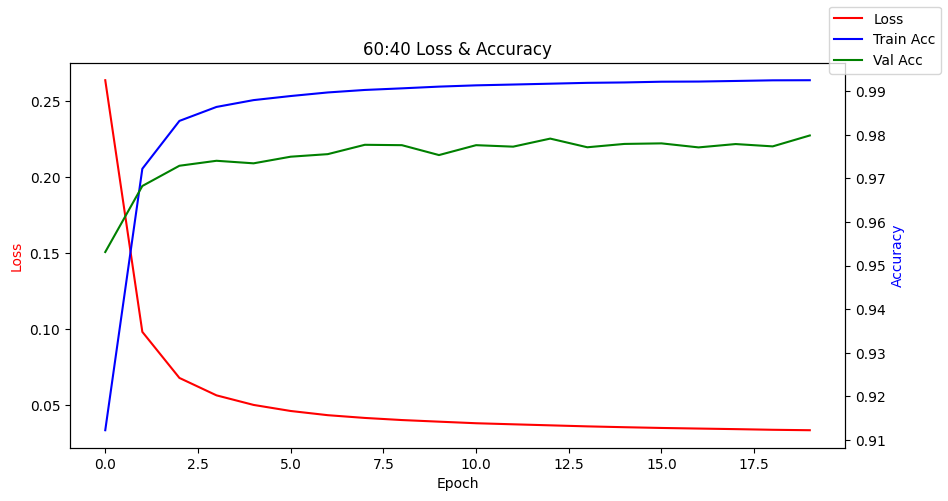

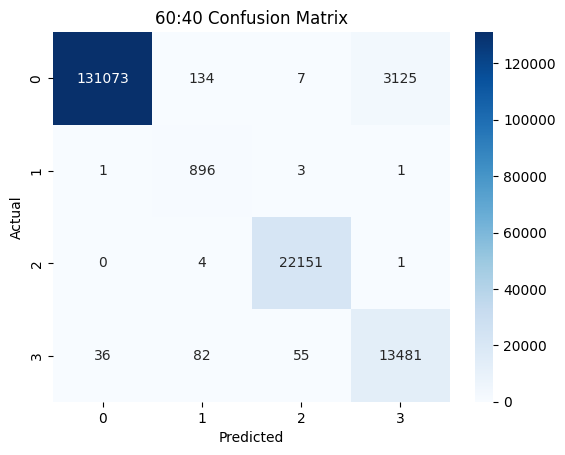

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.80      0.99      0.89       901
           2       1.00      1.00      1.00     22156
           3       0.81      0.99      0.89     13654

    accuracy                           0.98    171050
   macro avg       0.90      0.99      0.94    171050
weighted avg       0.98      0.98      0.98    171050



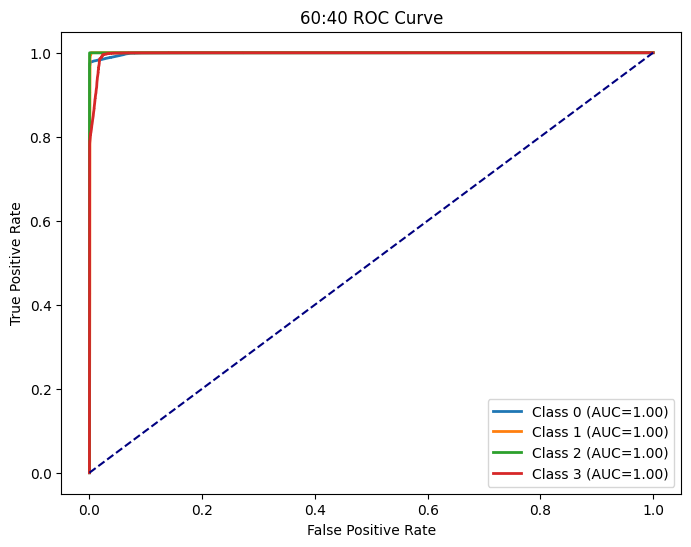

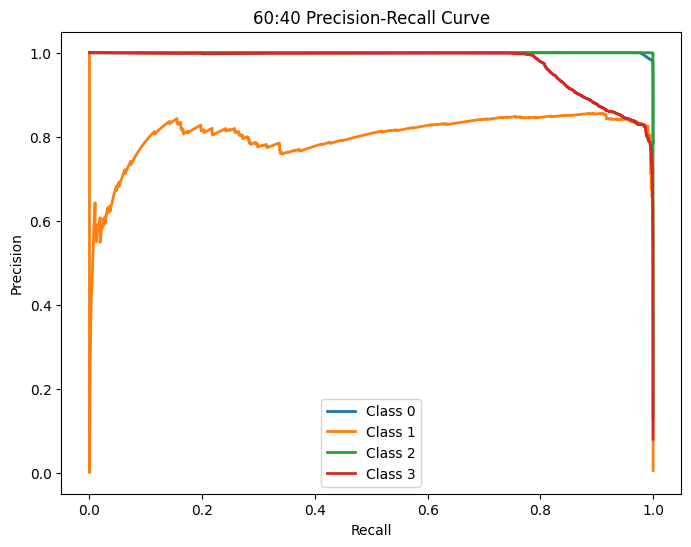


⏱️ Runtime for 60:40: 2768.06 sec
💾 RAM used for 60:40: 280.14 MB

========== 70:30 ==========
Train distribution BEFORE ADASYN+Tomek:


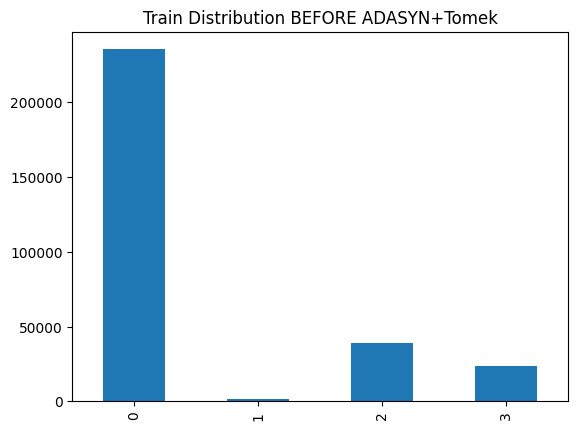

Train distribution AFTER ADASYN+Tomek:


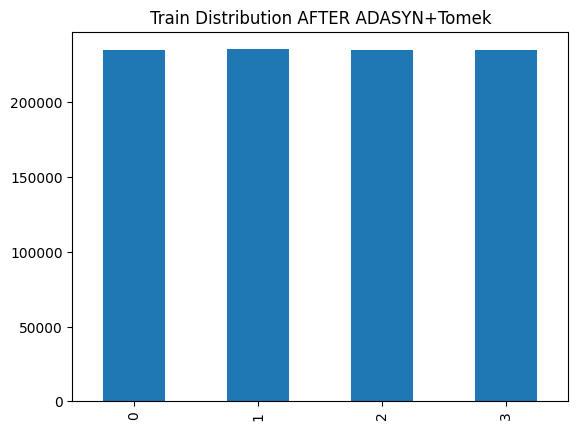

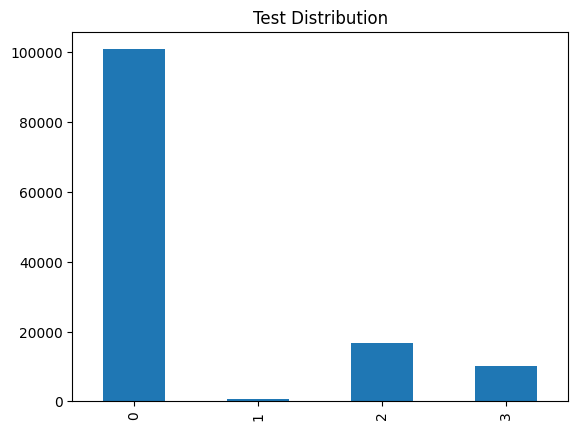

Train size: 939796
Test size : 128288
Epoch 1: Loss=0.2113, TrainAcc=0.9287, TestAcc=0.9679, ROC-AUC=0.9954
Epoch 2: Loss=0.0797, TrainAcc=0.9788, TestAcc=0.9711, ROC-AUC=0.9974
Epoch 3: Loss=0.0547, TrainAcc=0.9873, TestAcc=0.9756, ROC-AUC=0.9988
Epoch 4: Loss=0.0450, TrainAcc=0.9894, TestAcc=0.9774, ROC-AUC=0.9989
Epoch 5: Loss=0.0412, TrainAcc=0.9905, TestAcc=0.9769, ROC-AUC=0.9992
Epoch 6: Loss=0.0381, TrainAcc=0.9913, TestAcc=0.9796, ROC-AUC=0.9992
Epoch 7: Loss=0.0359, TrainAcc=0.9918, TestAcc=0.9798, ROC-AUC=0.9993
Epoch 8: Loss=0.0340, TrainAcc=0.9923, TestAcc=0.9804, ROC-AUC=0.9992
Epoch 9: Loss=0.0326, TrainAcc=0.9927, TestAcc=0.9819, ROC-AUC=0.9993
Epoch 10: Loss=0.0313, TrainAcc=0.9931, TestAcc=0.9824, ROC-AUC=0.9993
Epoch 11: Loss=0.0302, TrainAcc=0.9934, TestAcc=0.9823, ROC-AUC=0.9994
Epoch 12: Loss=0.0293, TrainAcc=0.9936, TestAcc=0.9829, ROC-AUC=0.9993
Epoch 13: Loss=0.0287, TrainAcc=0.9936, TestAcc=0.9842, ROC-AUC=0.9994
Epoch 14: Loss=0.0281, TrainAcc=0.9938, TestAcc=

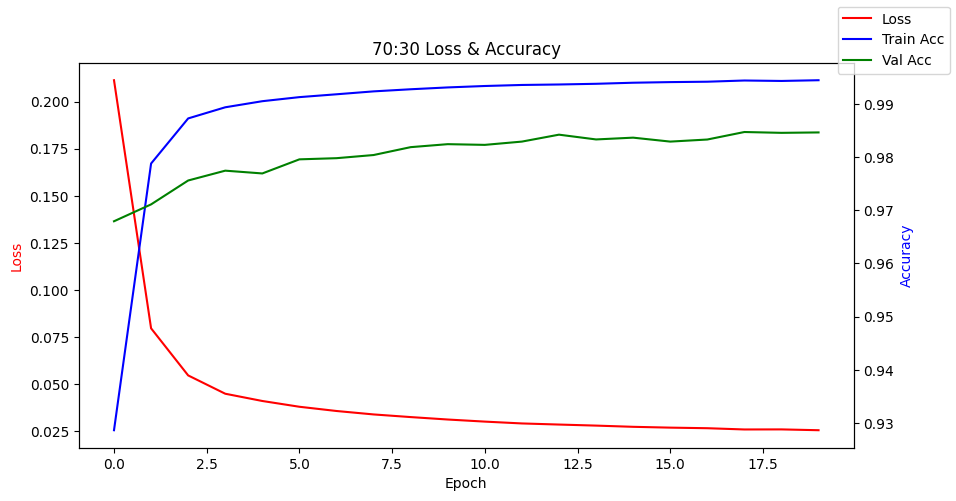

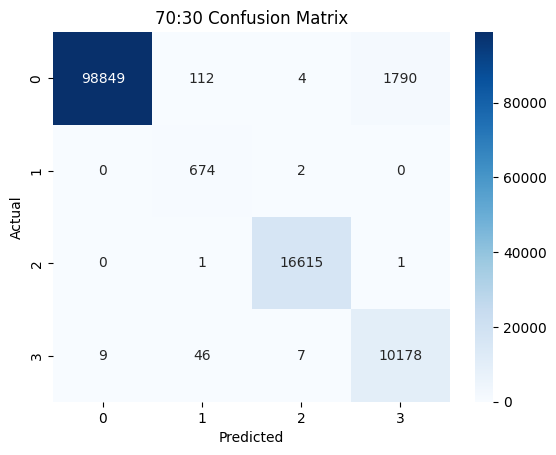

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.81      1.00      0.89       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.99      0.92     10240

    accuracy                           0.98    128288
   macro avg       0.91      0.99      0.95    128288
weighted avg       0.99      0.98      0.99    128288



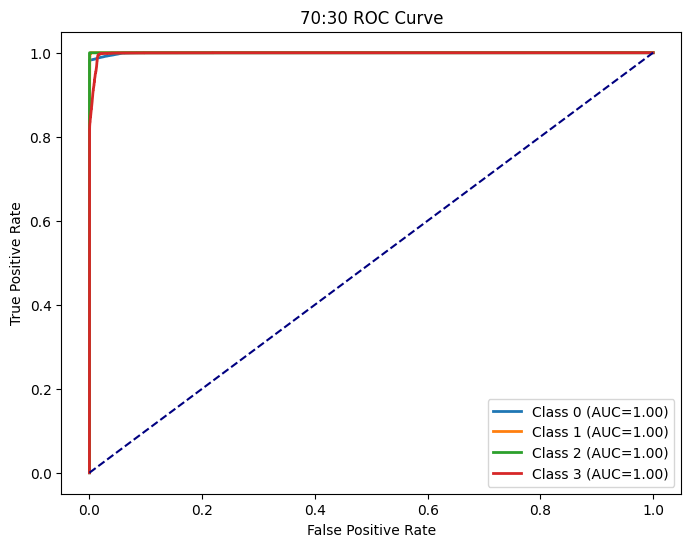

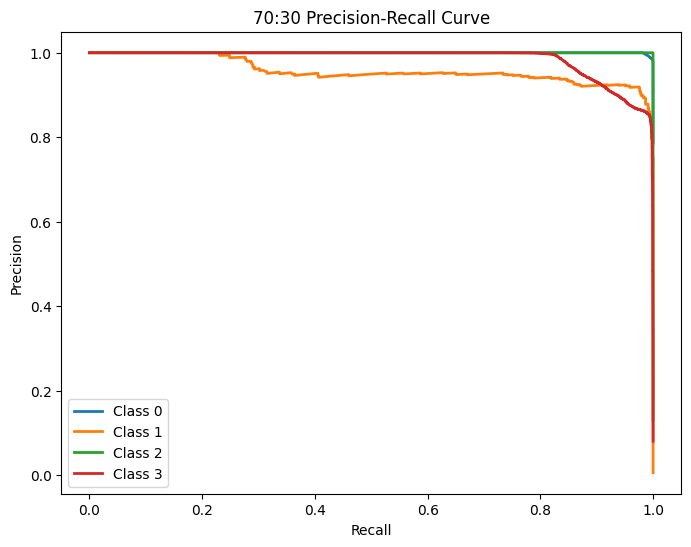


⏱️ Runtime for 70:30: 3543.70 sec
💾 RAM used for 70:30: 336.43 MB

========== 80:20 ==========
Train distribution BEFORE ADASYN+Tomek:


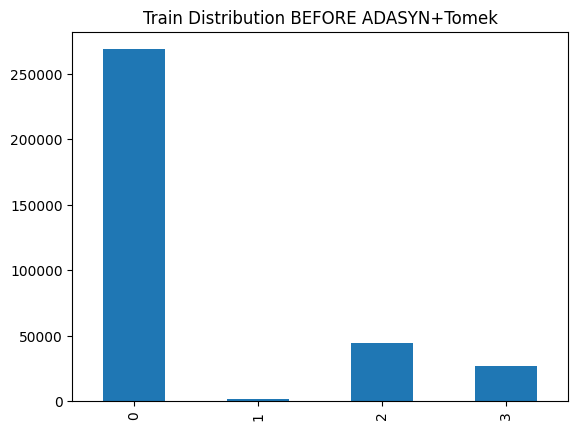

Train distribution AFTER ADASYN+Tomek:


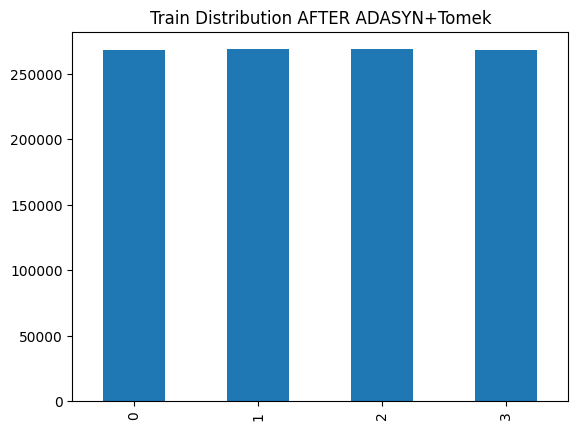

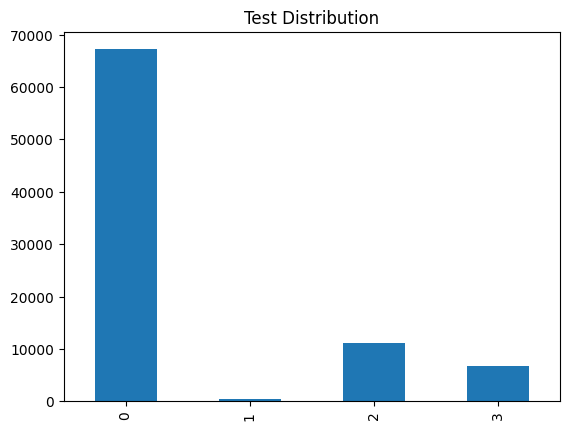

Train size: 1074178
Test size : 85525
Epoch 1: Loss=0.2283, TrainAcc=0.9235, TestAcc=0.9542, ROC-AUC=0.9942
Epoch 2: Loss=0.0867, TrainAcc=0.9772, TestAcc=0.9698, ROC-AUC=0.9962
Epoch 3: Loss=0.0640, TrainAcc=0.9852, TestAcc=0.9731, ROC-AUC=0.9971
Epoch 4: Loss=0.0540, TrainAcc=0.9875, TestAcc=0.9744, ROC-AUC=0.9977
Epoch 5: Loss=0.0478, TrainAcc=0.9890, TestAcc=0.9768, ROC-AUC=0.9983
Epoch 6: Loss=0.0439, TrainAcc=0.9900, TestAcc=0.9773, ROC-AUC=0.9985
Epoch 7: Loss=0.0415, TrainAcc=0.9906, TestAcc=0.9762, ROC-AUC=0.9986
Epoch 8: Loss=0.0397, TrainAcc=0.9911, TestAcc=0.9786, ROC-AUC=0.9987
Epoch 9: Loss=0.0385, TrainAcc=0.9914, TestAcc=0.9778, ROC-AUC=0.9986
Epoch 10: Loss=0.0374, TrainAcc=0.9917, TestAcc=0.9786, ROC-AUC=0.9988
Epoch 11: Loss=0.0366, TrainAcc=0.9919, TestAcc=0.9795, ROC-AUC=0.9989
Epoch 12: Loss=0.0360, TrainAcc=0.9920, TestAcc=0.9774, ROC-AUC=0.9988
Epoch 13: Loss=0.0354, TrainAcc=0.9922, TestAcc=0.9794, ROC-AUC=0.9989
Epoch 14: Loss=0.0347, TrainAcc=0.9923, TestAcc=

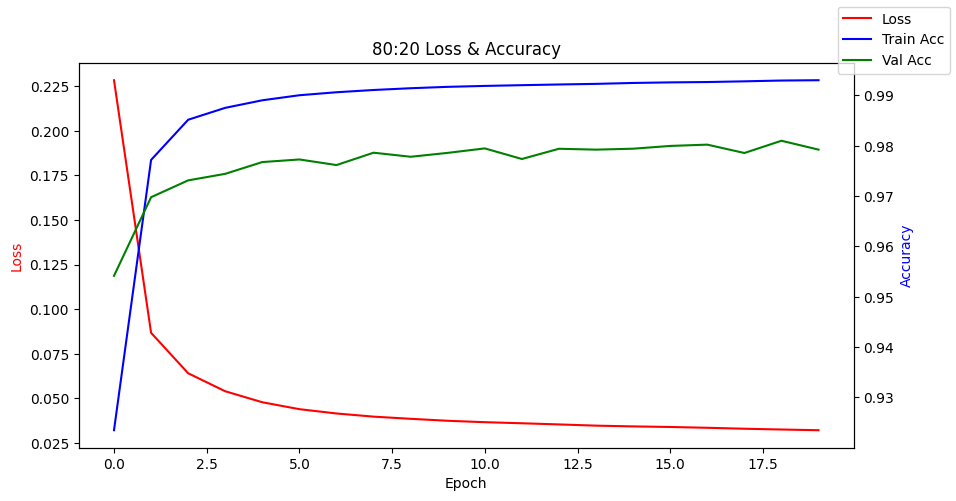

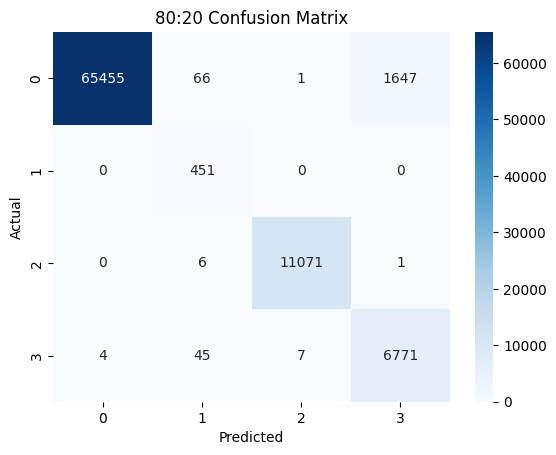

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     67169
           1       0.79      1.00      0.89       451
           2       1.00      1.00      1.00     11078
           3       0.80      0.99      0.89      6827

    accuracy                           0.98     85525
   macro avg       0.90      0.99      0.94     85525
weighted avg       0.98      0.98      0.98     85525



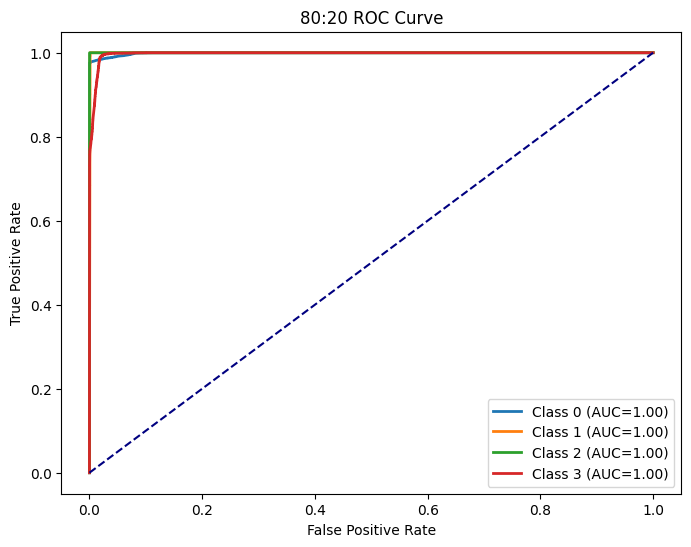

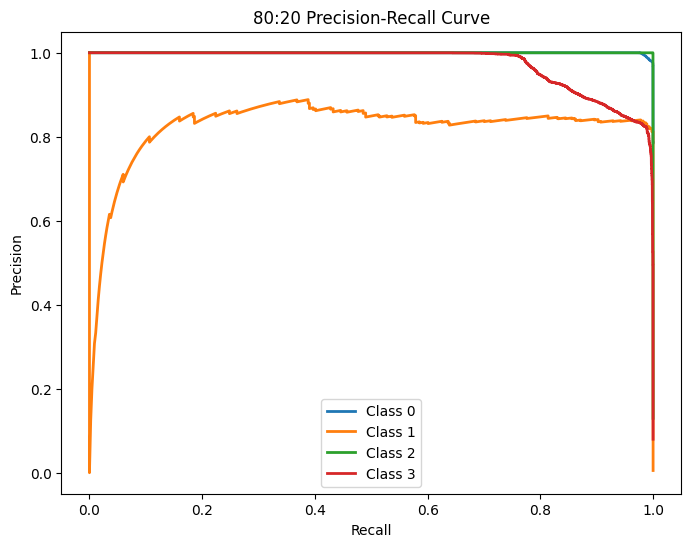


⏱️ Runtime for 80:20: 4379.12 sec
💾 RAM used for 80:20: 392.61 MB


In [42]:
# ---------------- MAIN ---------------- #

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)